# HW 4 Q2

## 2-2:

2-2-2:

In [254]:
# markovmodel:
import torch
import torch.nn as nn

# markov
class MarkovPredictor(nn.Module):
    def __init__(self, input_size, output_size ,dropout=0.5):
        super(MarkovPredictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_size),
            nn.Dropout(dropout),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

In [255]:
#gru:
class GRUModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, output_size=20 , dropout=0.5):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):  
        out, _ = self.gru(x)  
        out = self.dropout(out)
        out = self.fc(out) 
        return self.sigmoid(out)

In [256]:
# bi gru:
class BiGRUModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, output_size=20, dropout =0.5):
        super(BiGRUModel, self).__init__()

        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out)
        out = self.fc(out)
        return self.sigmoid(out)

In [257]:
# lstm:
class LSTMModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, output_size=20, dropout=0.5):
        super(LSTMModel, self).__init__()

        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        out = self.fc(out)
        return self.sigmoid(out)

In [258]:
# bi lstm:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, output_size=20, dropout =0.5):
        super(BiLSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        out = self.fc(out)
        return self.sigmoid(out)

In [259]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [260]:
from torchinfo import summary
# create models:

lr= 0.005
batch_size =16
input_size=20
output_size = 20
dropout=0.5
hidden_size=128
win_len = 24
markov_0 = MarkovPredictor(input_size=input_size, output_size=output_size,dropout=0).to(device) # without frop out
markov = MarkovPredictor(input_size=input_size, output_size=output_size,dropout=dropout).to(device)
gru = GRUModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size, dropout=dropout).to(device)
bigru = BiGRUModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size, dropout=dropout).to(device)
lstm = LSTMModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size, dropout=dropout).to(device)
bilstm = BiLSTMModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size, dropout=dropout).to(device)

summary:

In [261]:
import torchsummary
torchsummary.summary(markov, input_size=(input_size,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           2,688
           Dropout-2                  [-1, 128]               0
              ReLU-3                  [-1, 128]               0
       BatchNorm1d-4                  [-1, 128]             256
            Linear-5                   [-1, 20]           2,580
           Dropout-6                   [-1, 20]               0
           Sigmoid-7                   [-1, 20]               0
Total params: 5,524
Trainable params: 5,524
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.03
----------------------------------------------------------------


In [262]:
summary(gru, input_size=(batch_size, win_len, input_size))

Layer (type:depth-idx)                   Output Shape              Param #
GRUModel                                 [16, 24, 20]              --
├─GRU: 1-1                               [16, 24, 128]             57,600
├─Dropout: 1-2                           [16, 24, 128]             --
├─Linear: 1-3                            [16, 24, 20]              2,580
├─Sigmoid: 1-4                           [16, 24, 20]              --
Total params: 60,180
Trainable params: 60,180
Non-trainable params: 0
Total mult-adds (M): 22.16
Input size (MB): 0.03
Forward/backward pass size (MB): 0.45
Params size (MB): 0.24
Estimated Total Size (MB): 0.73

In [263]:
summary(bigru, input_size=(batch_size, win_len, input_size))

Layer (type:depth-idx)                   Output Shape              Param #
BiGRUModel                               [16, 24, 20]              --
├─GRU: 1-1                               [16, 24, 256]             115,200
├─Dropout: 1-2                           [16, 24, 256]             --
├─Linear: 1-3                            [16, 24, 20]              5,140
├─Sigmoid: 1-4                           [16, 24, 20]              --
Total params: 120,340
Trainable params: 120,340
Non-trainable params: 0
Total mult-adds (M): 44.32
Input size (MB): 0.03
Forward/backward pass size (MB): 0.85
Params size (MB): 0.48
Estimated Total Size (MB): 1.36

In [264]:
summary(lstm, input_size=(batch_size, win_len, input_size))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [16, 24, 20]              --
├─LSTM: 1-1                              [16, 24, 128]             76,800
├─Dropout: 1-2                           [16, 24, 128]             --
├─Linear: 1-3                            [16, 24, 20]              2,580
├─Sigmoid: 1-4                           [16, 24, 20]              --
Total params: 79,380
Trainable params: 79,380
Non-trainable params: 0
Total mult-adds (M): 29.53
Input size (MB): 0.03
Forward/backward pass size (MB): 0.45
Params size (MB): 0.32
Estimated Total Size (MB): 0.80

In [265]:
summary(bilstm, input_size=(batch_size, win_len, input_size))

Layer (type:depth-idx)                   Output Shape              Param #
BiLSTMModel                              [16, 24, 20]              --
├─LSTM: 1-1                              [16, 24, 256]             153,600
├─Dropout: 1-2                           [16, 24, 256]             --
├─Linear: 1-3                            [16, 24, 20]              5,140
├─Sigmoid: 1-4                           [16, 24, 20]              --
Total params: 158,740
Trainable params: 158,740
Non-trainable params: 0
Total mult-adds (M): 59.06
Input size (MB): 0.03
Forward/backward pass size (MB): 0.85
Params size (MB): 0.63
Estimated Total Size (MB): 1.51

## 2-3: preparing data and data analysis

### 2-3-1: 

In [266]:
import pandas as pd
import os
# to read the csv files:
base_dir = os.getcwd()

test_path = "test_data.csv"
train_path = "train_data.csv"
val_path = "val_data.csv"

test_path = os.path.join(base_dir, test_path)
train_path = os.path.join(base_dir, train_path)
val_path = os.path.join(base_dir, val_path)

test_df= pd.read_csv(test_path)
train_df= pd.read_csv(train_path)
val_df= pd.read_csv(val_path)


Show first 5 rows:

In [267]:
#showing first 5 rwos:
n = 5
print("test:")
test_df.head(n)


test:


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,303,303,51.0,100.0,37.1700,164.0,92.0,94.121951,21.0,33.029605,...,486.980139,735.583333,65.95,1,0.0,1.0,-0.02,304,0,3658
1,304,304,66.0,100.0,37.1825,154.0,92.0,94.024390,19.0,33.029605,...,486.830189,733.625000,65.95,1,0.0,1.0,-0.02,305,0,3658
2,305,305,82.0,97.0,37.1950,143.0,86.0,93.926829,21.0,33.029605,...,486.680238,731.666667,65.95,1,0.0,1.0,-0.02,306,0,3658
3,306,306,89.0,98.0,37.2075,147.0,85.0,93.829268,19.0,33.029605,...,486.530288,729.708333,65.95,1,0.0,1.0,-0.02,307,0,3658
4,307,307,56.0,100.0,37.2200,139.0,82.0,93.731707,19.0,33.029605,...,486.380338,727.750000,65.95,1,0.0,1.0,-0.02,308,0,3658


In [268]:
print("train:")
train_df.head(n)


train:


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,100,100,100.0,100.0,37.4275,129.0,87.0,68.0,21.0,33.029605,...,579.250,106.040000,27.92,1,0.0,1.0,-0.03,101,0,9
1,101,101,98.0,100.0,37.3300,132.0,85.0,66.0,20.0,33.029605,...,582.875,106.360000,27.92,1,0.0,1.0,-0.03,102,0,9
2,102,102,103.0,99.0,37.4100,121.0,75.0,58.0,26.0,33.029605,...,586.500,106.680000,27.92,1,0.0,1.0,-0.03,103,0,9
3,103,103,95.0,100.0,37.4900,122.0,81.0,64.0,33.0,33.029605,...,590.125,107.000000,27.92,1,0.0,1.0,-0.03,104,0,9
4,104,104,94.0,100.0,37.5700,129.0,81.0,63.0,23.0,33.029605,...,593.750,110.090909,27.92,1,0.0,1.0,-0.03,105,0,9


In [269]:
print("val:")
val_df.head(n)

val:


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,236,236,128.0,96.0,36.2800,149.0,113.0,92.0,28.5,33.029605,...,378.146104,726.000000,27.92,1,0.0,1.0,-0.03,237,0,9
1,237,237,129.0,94.0,37.0425,136.0,102.0,83.0,28.0,33.029605,...,376.746753,729.666667,27.92,1,0.0,1.0,-0.03,238,0,9
2,238,238,133.0,94.0,37.8050,141.0,106.0,86.0,33.0,33.029605,...,375.347403,733.333333,27.92,1,0.0,1.0,-0.03,239,0,9
3,239,239,137.0,94.0,38.5675,142.0,106.0,87.0,30.0,33.029605,...,373.948052,737.000000,27.92,1,0.0,1.0,-0.03,240,0,9
4,240,240,138.0,96.0,39.3300,142.0,108.0,87.0,30.5,33.029605,...,372.548701,740.666667,27.92,1,0.0,1.0,-0.03,241,0,9


In [270]:
import matplotlib.pyplot as plt
# first column is unnamed 0 and its values are same as Hour, so i will remove them:
for df in [train_df, val_df, test_df]:
    if df.columns[0] != 'Hour' and df.iloc[:, 0].equals(df['Hour']):
        df.drop(columns=df.columns[0], inplace=True)


# some features are not features that need to be considered in the data correlation: like patient id
non_feature_cols = [
    'Hour','Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime',
    'ICULOS', 'SepsisLabel', 'Patient_ID'
]
# non_feature_cols = []
features_df= val_df.drop(columns=non_feature_cols)

# calc correlation matrix:
correlation_matrix = features_df.corr()
correlation_matrix = correlation_matrix.abs() # to see only postive values because we have negatice correlations too but only the abs(val) does matter here


<Figure size 640x480 with 0 Axes>

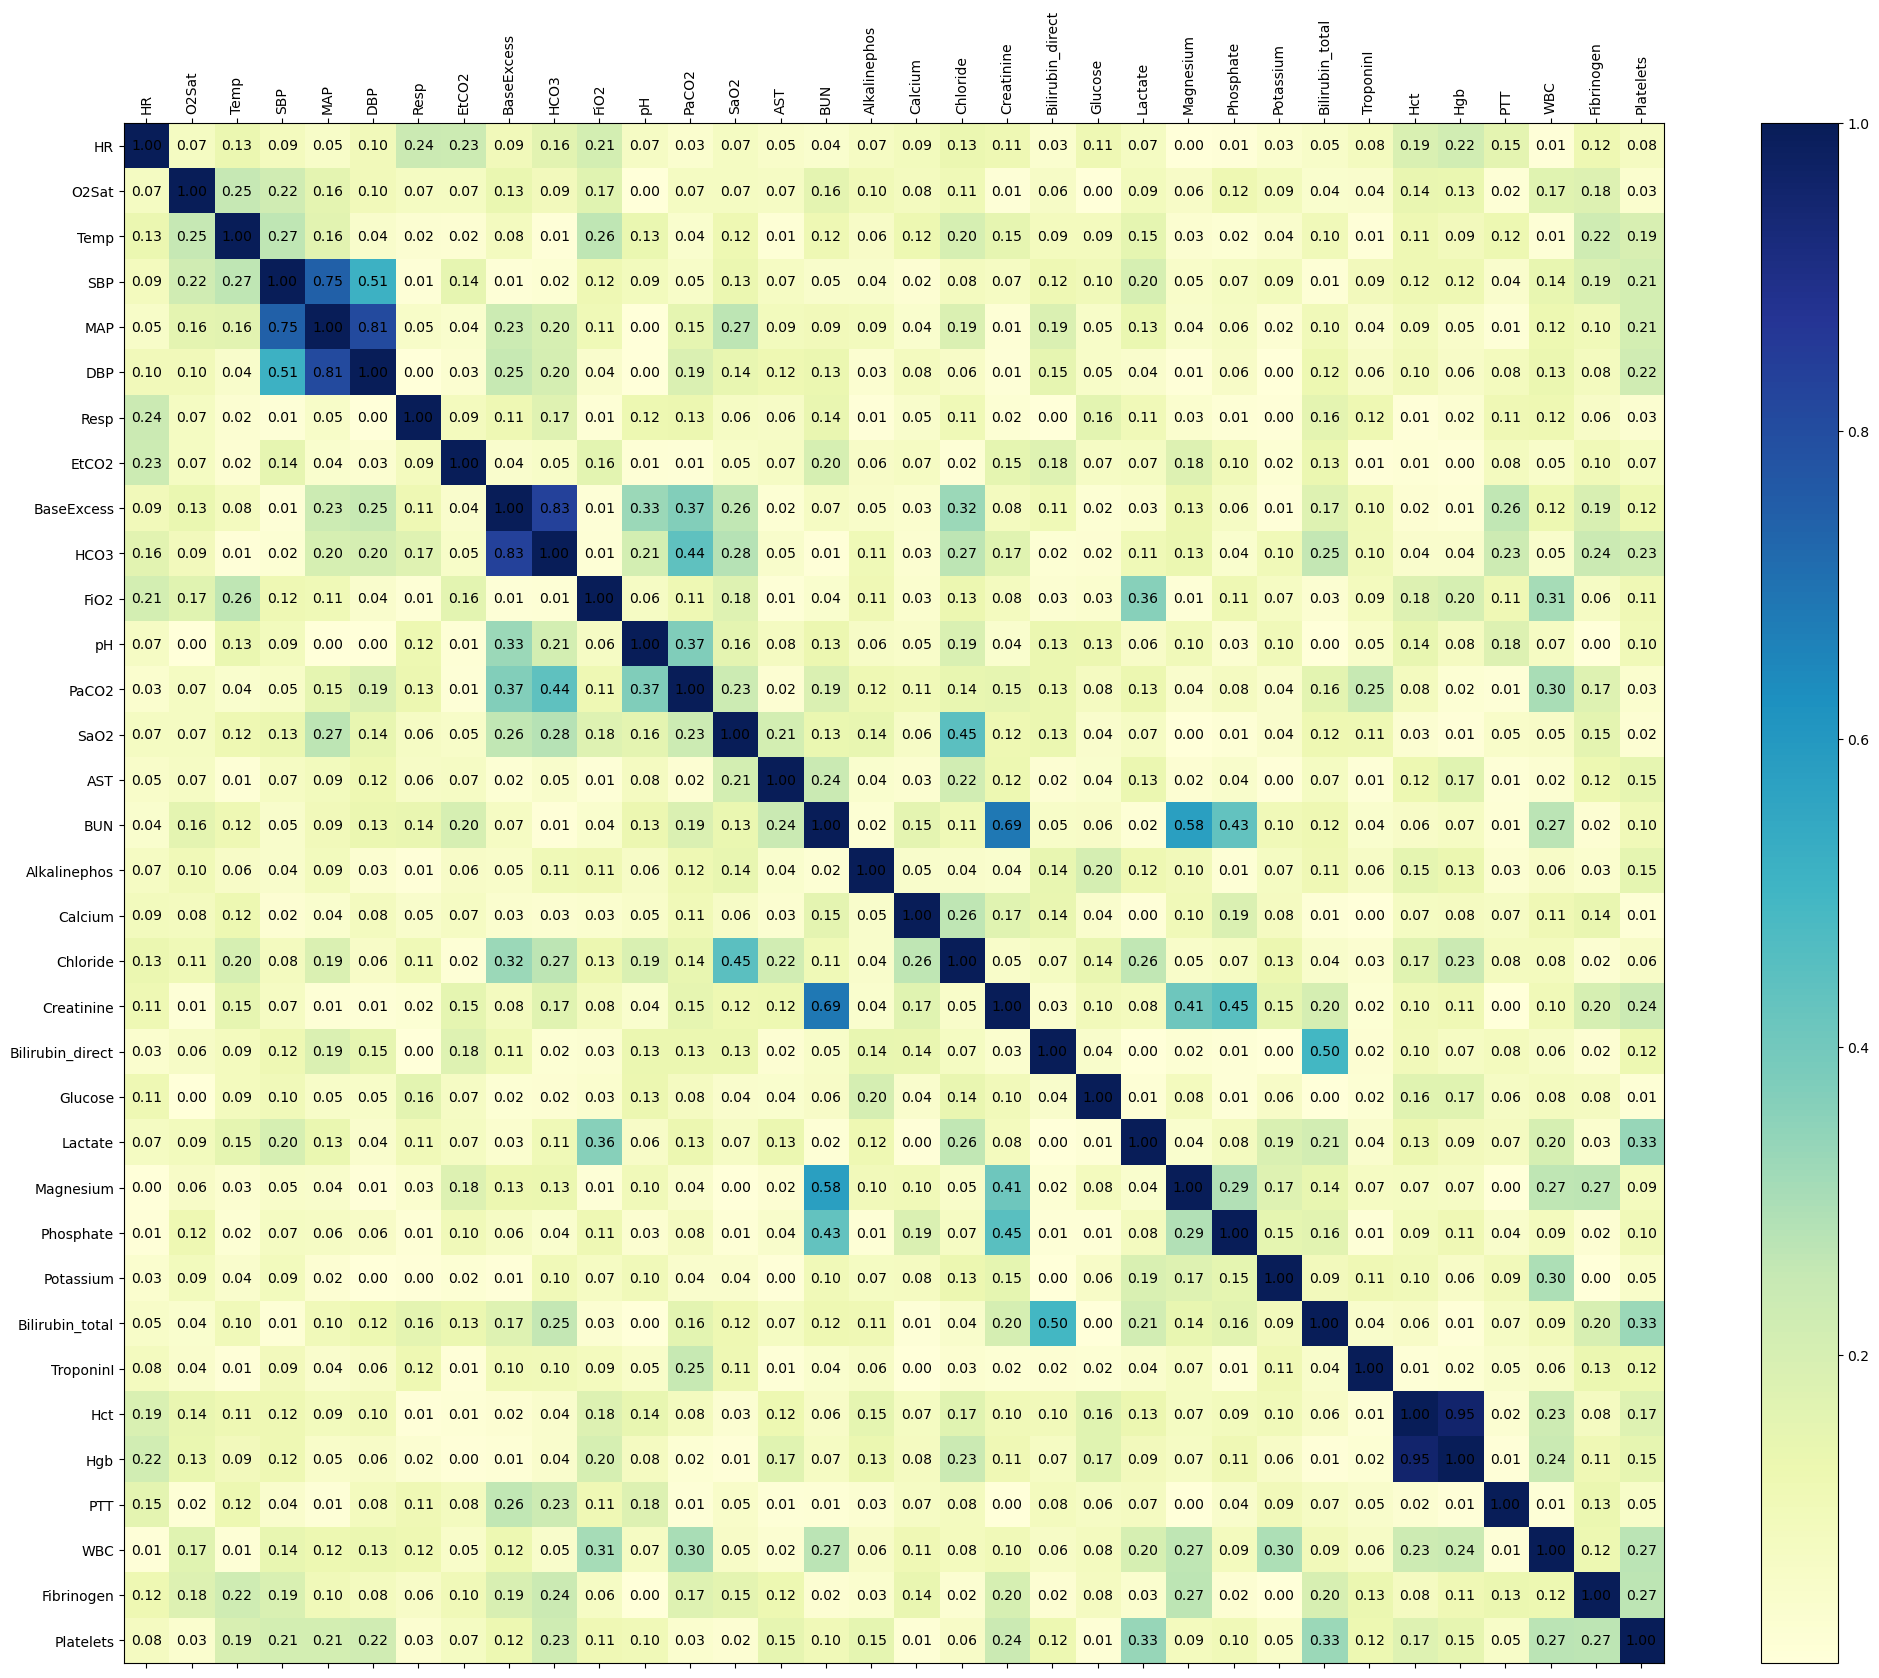

In [271]:

# Correlation plot: with diagonal or  self-correlation
plt.figure()

# Creating a heatmap manually
fig, ax = plt.subplots(figsize=(25, 20))
cax = ax.matshow(correlation_matrix, cmap="YlGnBu")
plt.colorbar(cax)

ax.set_xticks(range(len(features_df.columns)))
ax.set_yticks(range(len(features_df.columns)))
ax.set_xticklabels(features_df.columns, rotation=90)
ax.set_yticklabels(features_df.columns)

for i in range(len(features_df.columns)):
    for j in range(len(features_df.columns)):
        ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()


<Figure size 640x480 with 0 Axes>

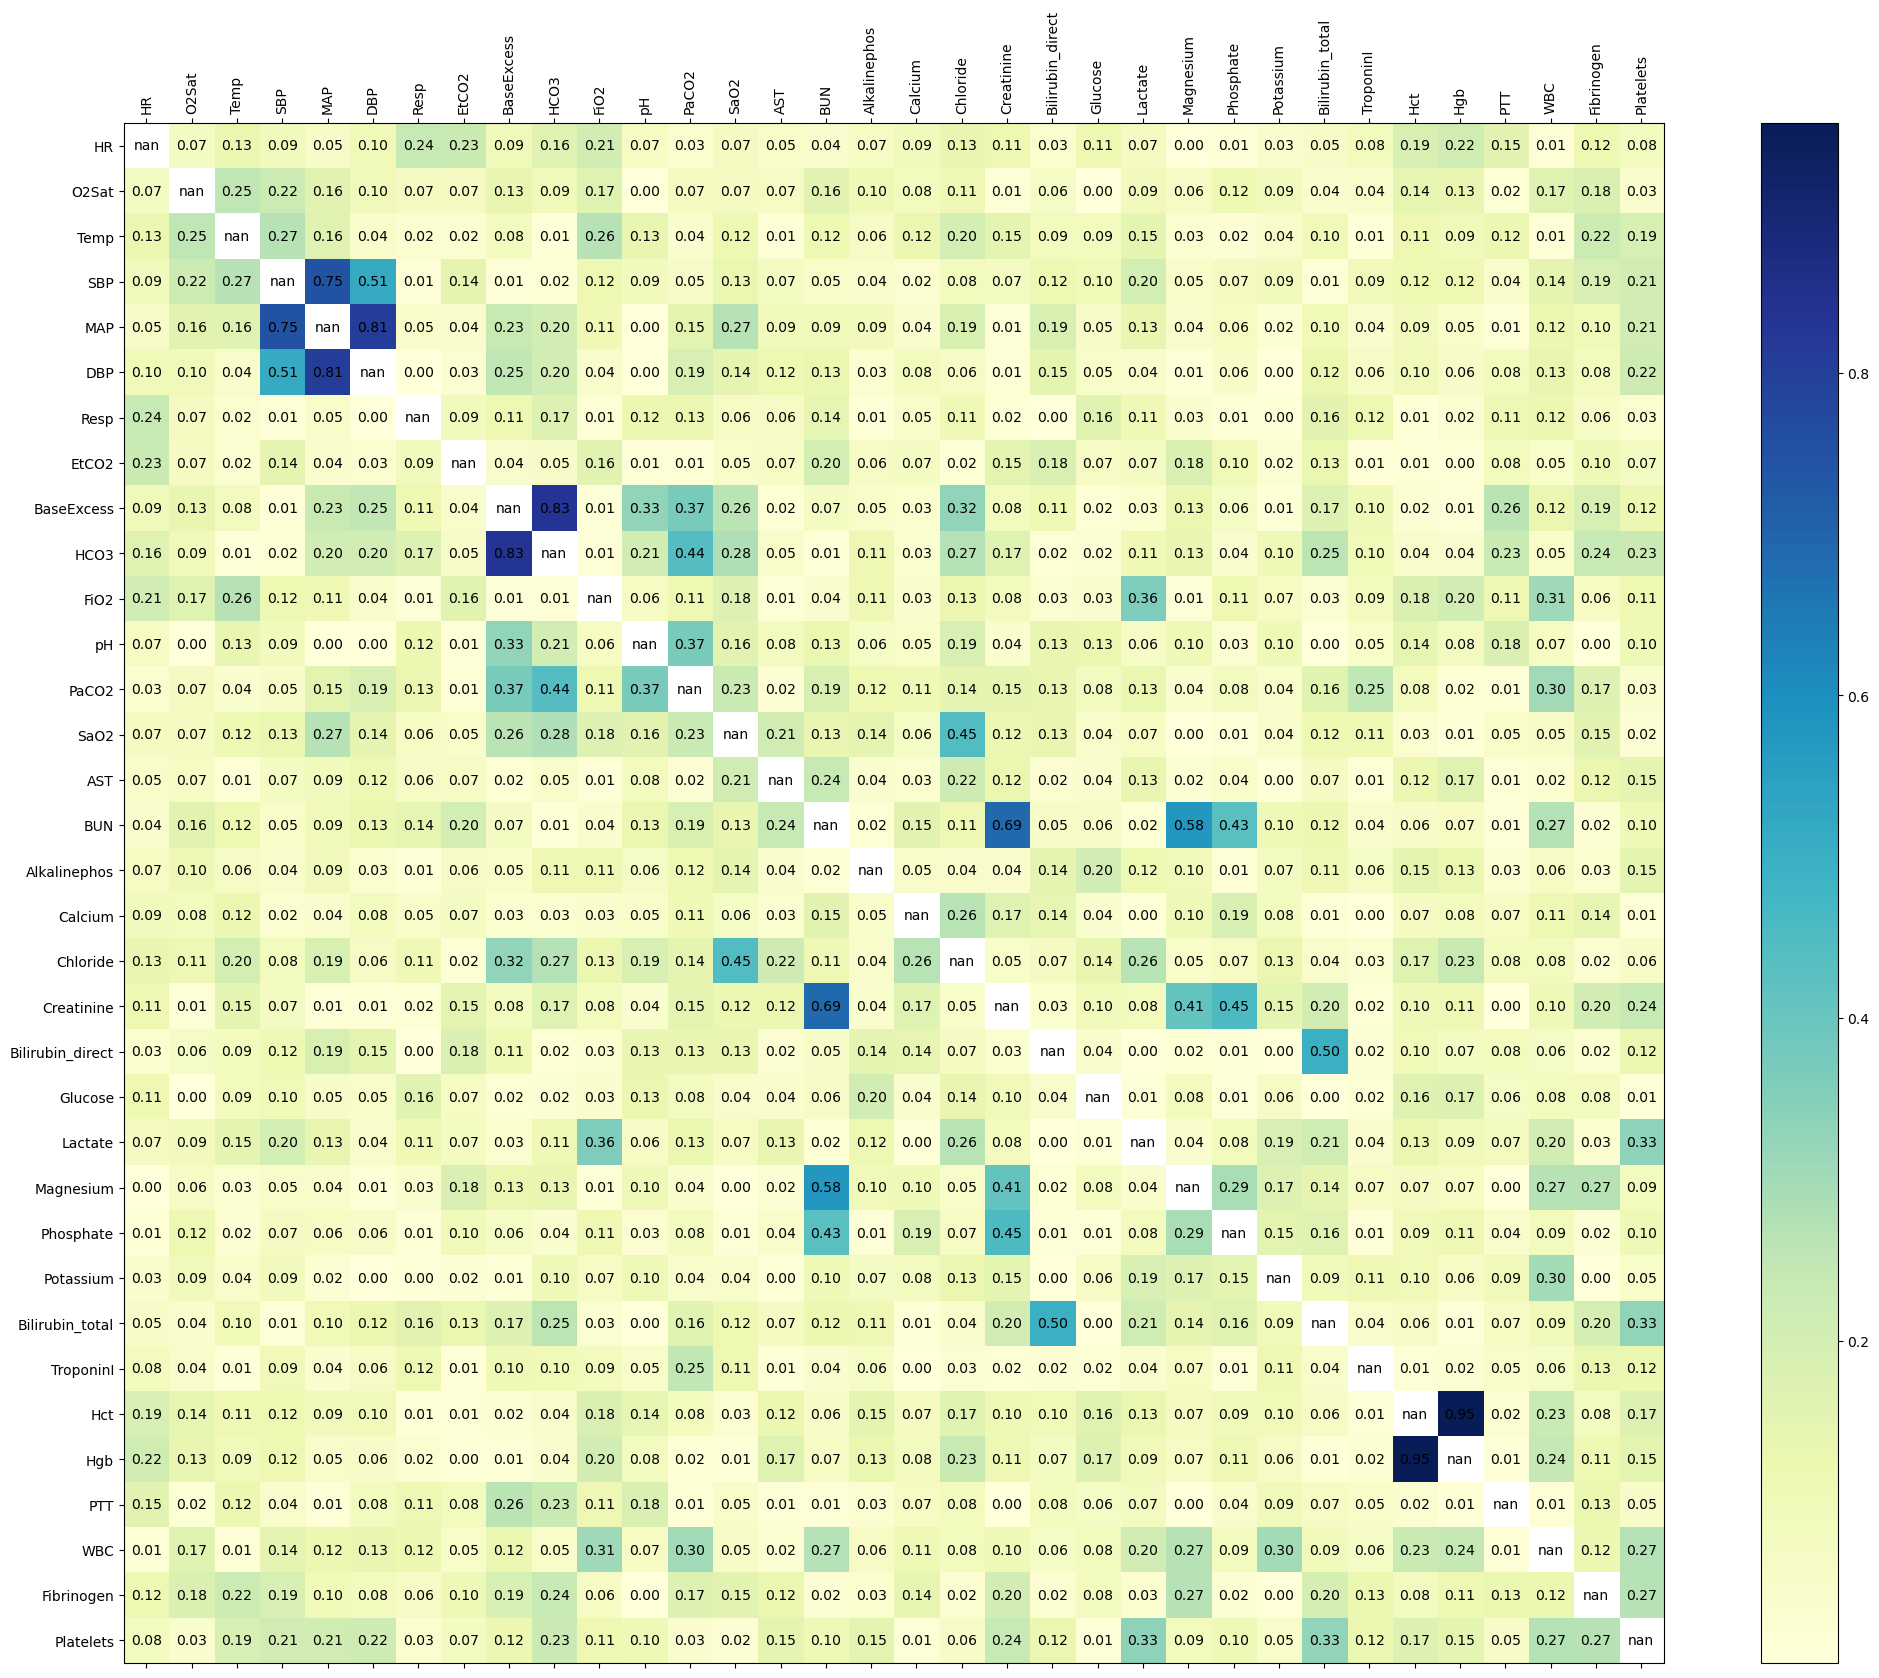

In [272]:
# Correlation plot: without diagonal or  self-correlation
for i in range(len(correlation_matrix)):
    correlation_matrix.iat[i, i] =None

plt.figure()

# Creating a heatmap manually
fig, ax = plt.subplots(figsize=(25, 20))
cax = ax.matshow(correlation_matrix, cmap="YlGnBu")
plt.colorbar(cax)

ax.set_xticks(range(len(features_df.columns)))
ax.set_yticks(range(len(features_df.columns)))
ax.set_xticklabels(features_df.columns, rotation=90)
ax.set_yticklabels(features_df.columns)

for i in range(len(features_df.columns)):
    for j in range(len(features_df.columns)):
        ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

selceted features are ['HR', 'PaCO2', 'Magnesium'] for under 0.05% 
['HR', 'PaCO2', 'Magnesium']


<Figure size 640x480 with 0 Axes>

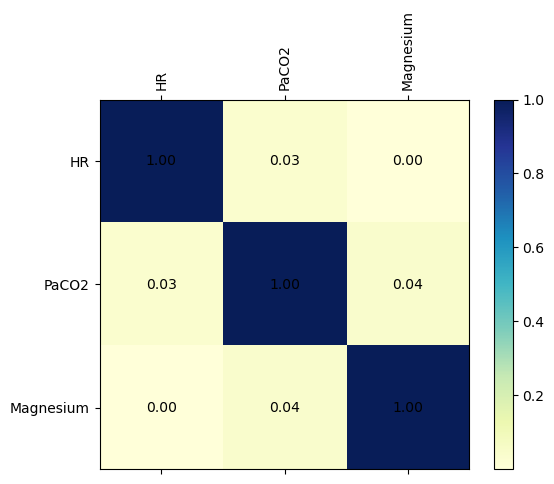

In [273]:
# to find correlations under 5%:
def find_correlations_under_percent(correlation_matrix, percent=0.05, max_features=20): # this is to find correlations under a certain percent
    selected = []
    columns = correlation_matrix.columns.tolist()

    for col in columns:
        if all(correlation_matrix.loc[col, s] <= percent for s in selected):
            selected.append(col)
        if len(selected) == max_features:
            break

    return selected

percent = 0.05
selected_features = find_correlations_under_percent(correlation_matrix, percent=percent, max_features=20)

print(f"selceted features are {selected_features} for under {percent}% ")
print(selected_features)

# plot selected features:
new_correlation_matrix = features_df[selected_features].corr().abs()
plt.figure()

fig, ax = plt.subplots()
cax = ax.matshow(new_correlation_matrix, cmap="YlGnBu")
plt.colorbar(cax)

ax.set_xticks(range(len(new_correlation_matrix.columns)))
ax.set_yticks(range(len(new_correlation_matrix.columns)))
ax.set_xticklabels(new_correlation_matrix.columns, rotation=90)
ax.set_yticklabels(new_correlation_matrix.columns)

for i in range(len(new_correlation_matrix.columns)):
    for j in range(len(new_correlation_matrix.columns)):
        ax.text(j, i, f'{new_correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

In [274]:
# find lowest correaltions:
avg_corr = correlation_matrix.mean(axis=1)
lowest_20_features = avg_corr.nsmallest(20).index.tolist()
print("20 features with lowest correlation are:")
print(lowest_20_features)

20 features with lowest correlation are:
['TroponinI', 'Glucose', 'PTT', 'Resp', 'AST', 'Calcium', 'Potassium', 'EtCO2', 'Alkalinephos', 'Bilirubin_direct', 'Phosphate', 'O2Sat', 'HR', 'pH', 'Temp', 'FiO2', 'Magnesium', 'Lactate', 'Fibrinogen', 'Hgb']


In [275]:
# group based on the 20 features:
test_grouped_by_patient = test_df[['Hour']+['Patient_ID'] + lowest_20_features].groupby('Patient_ID')
train_grouped_by_patient = train_df[['Hour']+['Patient_ID'] + lowest_20_features].groupby('Patient_ID')
val_grouped_by_patient = val_df[['Hour']+['Patient_ID'] + lowest_20_features].groupby('Patient_ID')

# verify: 
# Show first patient ID
first_patient_id = list(test_grouped_by_patient.groups.keys())[0]
print(f"First Patient ID: {first_patient_id}")

# Show data for the first patient
first_patient_test_data = val_grouped_by_patient.get_group(first_patient_id)
print("Data for the first patient:")
first_patient_test_data.head(2)


First Patient ID: 3658
Data for the first patient:


,Hour,Patient_ID,TroponinI,Glucose,PTT,Resp,AST,Calcium,Potassium,EtCO2,...,Phosphate,O2Sat,HR,pH,Temp,FiO2,Magnesium,Lactate,Fibrinogen,Hgb
166,236,3658,10.161432,140.090909,22.483636,17.222222,55.819113,8.454545,3.736364,33.029605,...,2.718182,100.0,73.0,7.4820,37.382,0.35,2.554545,1.390127,497.026812,8.728
167,237,3658,10.163802,139.909091,22.536364,17.111111,55.660410,8.445455,3.763636,33.029605,...,2.681818,100.0,85.0,7.4814,37.204,0.35,2.545455,1.398089,496.876862,8.740


## 2-3-2:

show HR time series

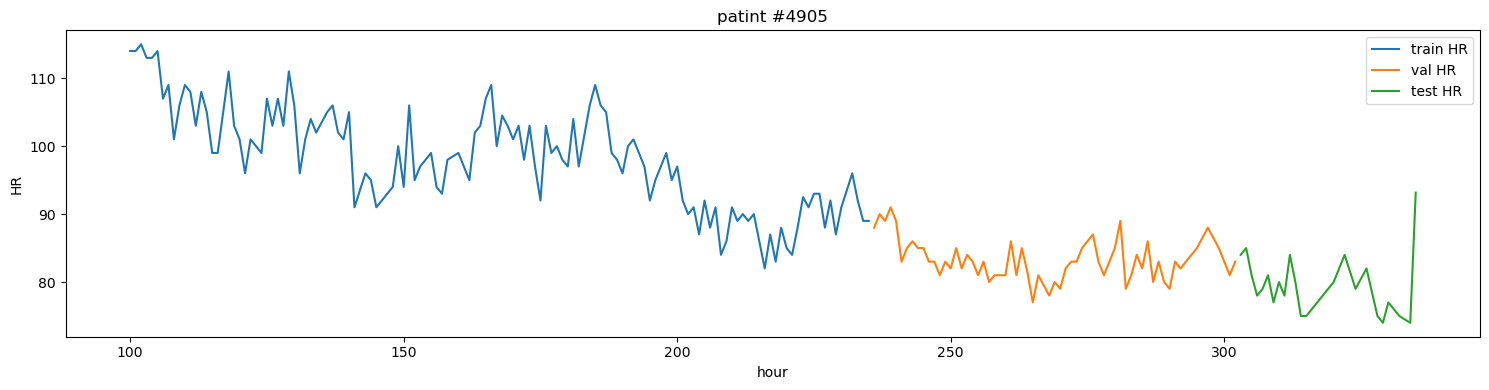

In [276]:
# i use a patient number in the test :
patient_id = list(test_grouped_by_patient.groups.keys())[1]
# extract data fir the first person:
first_person_train_HR= train_df[train_df['Patient_ID'] == patient_id]['HR'].dropna()
first_person_val_HR= val_df[val_df['Patient_ID'] == patient_id]['HR'].dropna()
first_person_test_HR= test_df[test_df['Patient_ID'] == patient_id]['HR'].dropna()

first_person_train_Hour= train_df[train_df['Patient_ID'] == patient_id]['Hour'].dropna()
first_person_val_Hour= val_df[val_df['Patient_ID'] == patient_id]['Hour'].dropna()
first_person_test_Hour= test_df[test_df['Patient_ID'] == patient_id]['Hour'].dropna()
# plot the HR time series::

plt.figure(figsize=(15, 4))
plt.plot(first_person_train_Hour,first_person_train_HR.values, label='train HR')
plt.plot(first_person_val_Hour, first_person_val_HR.values, label='val HR')
plt.plot(first_person_test_Hour, first_person_test_HR.values, label='test HR')
plt.title(f"patint #{patient_id}")
plt.xlabel("hour")
plt.ylabel("HR")
plt.legend()
plt.tight_layout()
plt.show()

ADF test

In [277]:
from statsmodels.tsa.stattools import adfuller
# find d:
d =0
hr_data = first_person_train_HR.copy().dropna()
while 1:
    result= adfuller(hr_data)
    pvalue= result[1]
    print(f"d : {d}, pvalue: {pvalue}")

    if pvalue<0.05:
        break
    else:
        hr_data=hr_data.diff()
        hr_data= hr_data.dropna() # remove NOne datas

        d +=1

print(f"d is {d}")


d : 0, pvalue: 0.3145065729994707
d : 1, pvalue: 9.425822961604211e-10
d is 1


## 2-3-3:

## autocorrelation and partial autcorrelation plots:

Text(0, 0.5, 'partial autcorrelation')

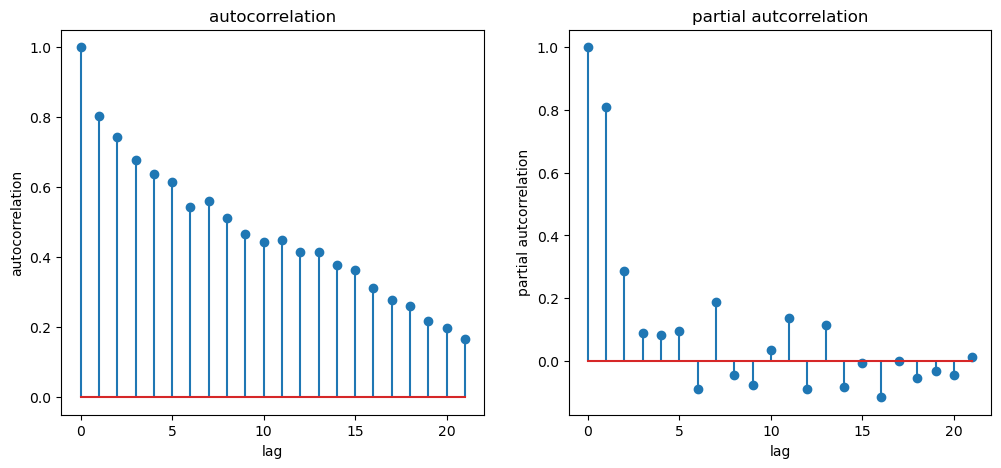

In [278]:
from statsmodels.tsa.stattools import acf, pacf
import numpy as np

hr_data = first_person_train_HR.copy().dropna()
acf_vals = acf(hr_data)
pacf_vals = pacf(hr_data)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.stem( acf_vals)
plt.title('autocorrelation')
plt.xlabel('lag')
plt.ylabel('autocorrelation')

plt.subplot(1,2,2)
plt.stem( pacf_vals)
plt.title('partial autcorrelation')
plt.xlabel('lag')
plt.ylabel('partial autcorrelation')


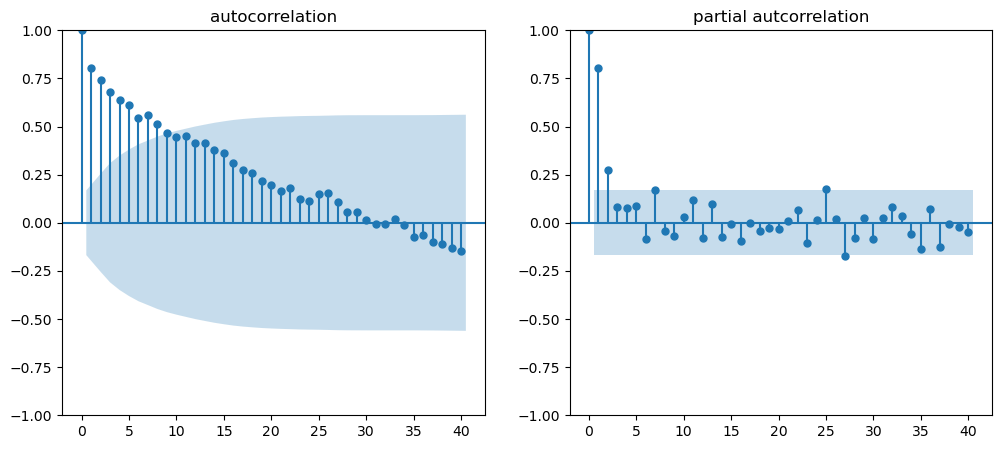

In [279]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
full_hr=first_person_train_HR.copy().dropna()
hr_series = full_hr.dropna()
hr_diff = hr_series.diff(d).dropna()

# ACF and PACF plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(full_hr, ax=plt.gca(), lags=40)
plt.title('autocorrelation')

plt.subplot(1, 2, 2)
plot_pacf(full_hr, ax=plt.gca(), lags=40)
plt.title('partial autcorrelation')
plt.show()

In [280]:
# from the plots:
AR = 2
p= AR
MA =3
q= MA

 train SAIMAX model:

In [281]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
first_person_train_O2Sat = train_df[train_df['Patient_ID'] == patient_id]['O2Sat'].dropna()
first_person_train_O2Sat = first_person_train_O2Sat.fillna(method='ffill').fillna(method='bfill')
model = SARIMAX(first_person_train_HR,first_person_train_O2Sat, order=(p,d,q),enforce_stationarity=False,enforce_invertibility=False)
model_fit = model.fit(disp=True)

predicted_HR_train= model_fit.fittedvalues


/tmp/ipykernel_50953/3983023170.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  first_person_train_O2Sat = first_person_train_O2Sat.fillna(method='ffill').fillna(method='bfill')
/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


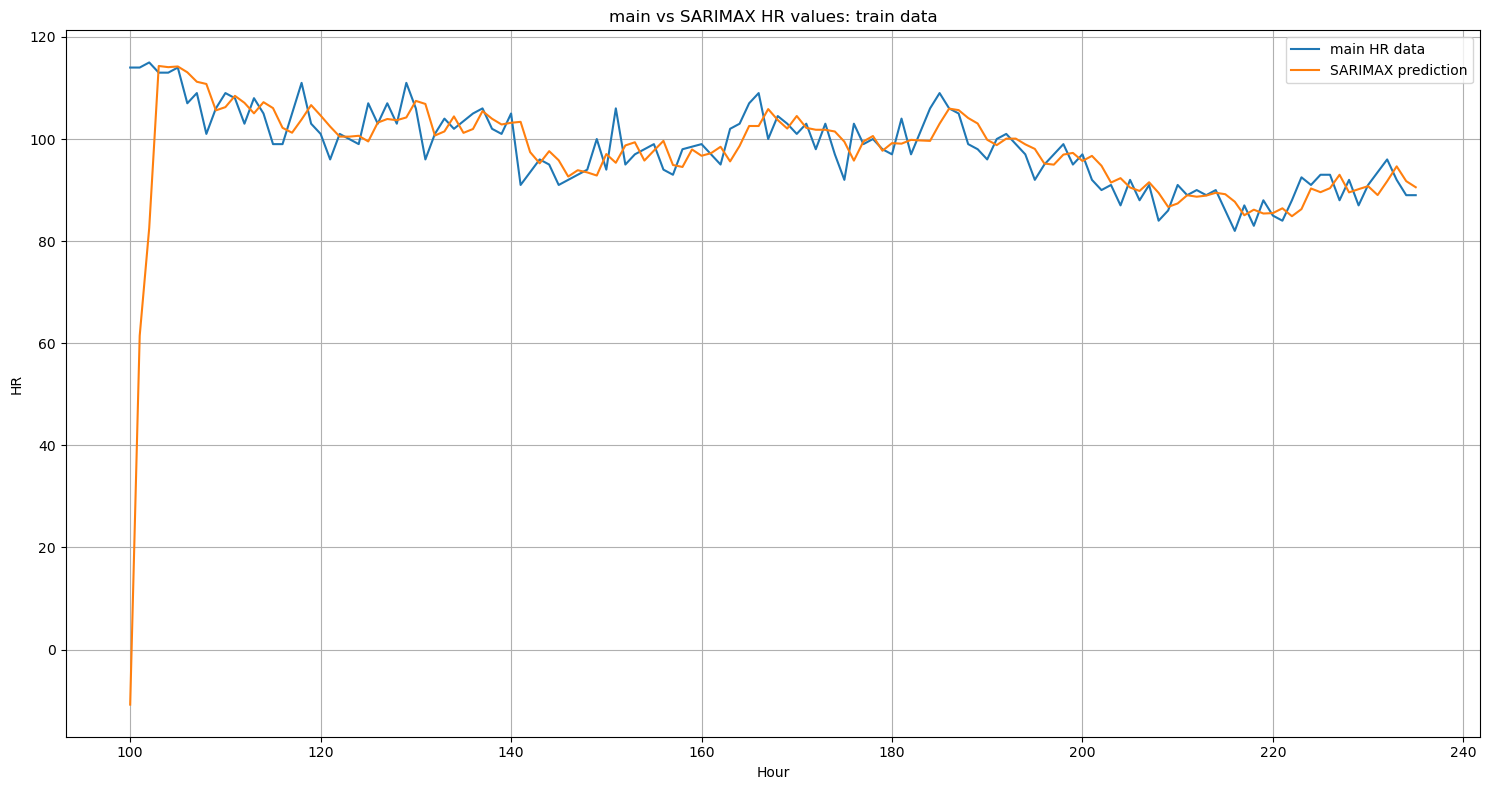

In [282]:
# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(first_person_train_Hour, first_person_train_HR, label='main HR data')
plt.plot(first_person_train_Hour, predicted_HR_train, label='SARIMAX prediction')
plt.title('main vs SARIMAX HR values: train data')
plt.xlabel("Hour")
plt.ylabel('HR')
plt.legend()
plt.grid(True)
plt.tight_layout()

## 2-3-4:

normalize data:

In [283]:
from sklearn.preprocessing import MinMaxScaler
non_feature_cols = [
    'Hour','Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime',
    'ICULOS', 'SepsisLabel', 'Patient_ID'
]

# train: 
feature_scaler = MinMaxScaler()
train_scaled = train_df.copy()
train_scaled[lowest_20_features] = feature_scaler.fit_transform(train_df[lowest_20_features])

hour_scaler = MinMaxScaler()
train_scaled['Hour'] = hour_scaler.fit_transform(train_df[['Hour']])

# val:
val_scaled = val_df.copy()
val_scaled[lowest_20_features] = feature_scaler.transform(val_df[lowest_20_features]) # I am using transform instead of fit_transdorm
val_scaled['Hour'] = hour_scaler.fit_transform(val_df[['Hour']]) 

test_scaled = test_df.copy()
test_scaled[lowest_20_features] = feature_scaler.transform(test_df[lowest_20_features])
test_scaled['Hour'] = hour_scaler.fit_transform(test_df[['Hour']])  

# group based on the 20 features:
test_scaled = test_scaled[['Hour']+['Patient_ID'] + lowest_20_features].groupby('Patient_ID')
train_scaled = train_scaled[['Hour']+['Patient_ID'] + lowest_20_features].groupby('Patient_ID')
val_scaled = val_scaled[['Hour']+['Patient_ID'] + lowest_20_features].groupby('Patient_ID')




In [284]:
test_scaled.head(5)

,Hour,Patient_ID,TroponinI,Glucose,PTT,Resp,AST,Calcium,Potassium,EtCO2,...,Phosphate,O2Sat,HR,pH,Temp,FiO2,Magnesium,Lactate,Fibrinogen,Hgb
0,0.00000,3658,0.063281,0.232875,0.016415,0.266667,0.004471,0.397766,0.273810,0.261700,...,0.371408,1.000000,0.128633,0.740946,0.519830,0.981859,0.212963,0.060418,0.337266,0.343210
1,0.03125,3658,0.063295,0.230586,0.016467,0.240000,0.004453,0.398196,0.272959,0.261700,...,0.373922,1.000000,0.204624,0.740022,0.521601,0.981859,0.212302,0.060751,0.337154,0.344444
2,0.06250,3658,0.063310,0.228296,0.016519,0.266667,0.004435,0.398625,0.272109,0.261700,...,0.376437,0.961538,0.285681,0.739098,0.523371,0.981859,0.211640,0.061084,0.337042,0.345679
3,0.09375,3658,0.063324,0.226007,0.016571,0.240000,0.004417,0.399055,0.271259,0.261700,...,0.378951,0.974359,0.321144,0.738174,0.525142,0.981859,0.210979,0.061417,0.336930,0.346914
4,0.12500,3658,0.063339,0.223717,0.016623,0.240000,0.004399,0.399485,0.270408,0.261700,...,0.381466,1.000000,0.153963,0.737250,0.526912,0.981859,0.210317,0.061749,0.336818,0.348148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,0.00000,119545,0.001625,0.126250,0.047936,0.346667,0.023932,0.370049,0.310956,0.284091,...,0.169716,0.897436,0.371805,0.810348,0.543909,0.987195,0.125651,0.033819,0.074549,0.587524
683,0.03125,119545,0.001621,0.121998,0.047944,0.340000,0.024075,0.369235,0.312030,0.272727,...,0.169321,0.910256,0.376871,0.811153,0.569405,0.987195,0.124682,0.033850,0.074504,0.585575
684,0.06250,119545,0.001617,0.117746,0.047952,0.380000,0.024218,0.368421,0.313104,0.301136,...,0.168926,0.910256,0.397135,0.811959,0.594901,0.987195,0.123713,0.033881,0.074459,0.583626
685,0.09375,119545,0.001613,0.103682,0.047960,0.360000,0.024360,0.367607,0.314178,0.238636,...,0.168531,0.910256,0.392069,0.812765,0.594901,0.987195,0.122743,0.033912,0.074415,0.581676


R2-score:

In [285]:
person_test_df = test_scaled.get_group(patient_id)
person_test_O2Sat = person_test_df['O2Sat'].dropna()
person_test_HR = person_test_df['HR'].dropna()
person_test_Hour = person_test_df['Hour'].dropna()

/tmp/ipykernel_50953/1228296916.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  first_person_test_O2Sat = first_person_test_O2Sat.fillna(method='ffill').fillna(method='bfill')
/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


r2-Score for test data is: -2.1861879121310377


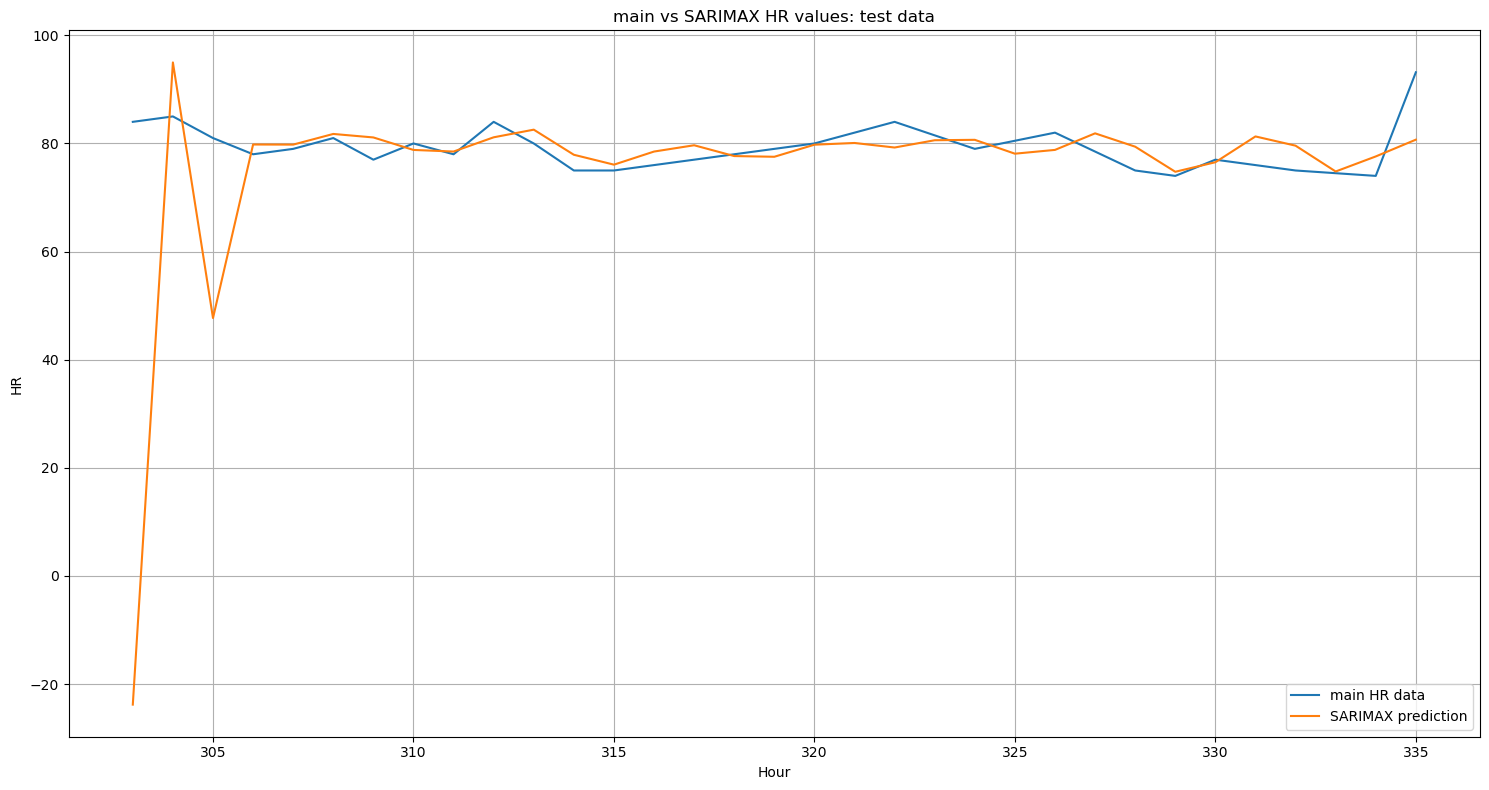

In [286]:
from sklearn.metrics import r2_score
import numpy as np
first_person_test_O2Sat = test_df[test_df['Patient_ID'] == patient_id]['O2Sat'].dropna()
first_person_test_O2Sat = first_person_test_O2Sat.fillna(method='ffill').fillna(method='bfill')

first_person_test_HR= test_df[test_df['Patient_ID']==patient_id]['HR'].dropna()
# calculate model output:
# forecast = model_fit.get_prediction(start=0, end=len(first_person_test_HR)-1, exog=first_person_test_O2Sat)
# model_fit.predict()
# predicted_hr = forecast.predicted_mean


model = SARIMAX(first_person_test_HR,first_person_test_O2Sat, order=(p,d,q),enforce_stationarity=False,enforce_invertibility=False)
model_fit = model.fit(disp=True)


predicted_HR= model_fit.fittedvalues
# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(first_person_test_Hour, first_person_test_HR, label='main HR data')
plt.plot(first_person_test_Hour, predicted_HR, label='SARIMAX prediction')
plt.title('main vs SARIMAX HR values: test data')
plt.xlabel("Hour")
plt.ylabel('HR')
plt.legend()
plt.grid(True)
plt.tight_layout()

# report r2 score:
r2 = r2_score(np.array(first_person_test_HR.values[1:]).reshape(-1), np.array(predicted_HR[1:]).reshape(-1)) # without first data which is wrong
print(f"r2-Score for test data is: {r2}")


## 2-4-1:

In [287]:
import torch
from torch.utils.data import Dataset

W_input = 12
W_output = 6

### pandas files:
# test_scaled
# train_scaled 
# val_scaled 
### using them:
# person_test_df = test_scaled.get_group(patient_id)
# person_test_O2Sat = person_test_df['O2Sat'].dropna()

# define data set class:
class MyDataset(Dataset):
    def __init__(self, grouped_df: pd.DataFrame, input_window=W_input, output_window=W_output,  feature_cols=None, label_cols=None): # label_cols are used for predictions

        self.input_window = input_window
        self.output_window = output_window
        self.samples = []

        if feature_cols is None:
            feature_cols = [col for col in grouped_df.obj.columns if col not in ['Patient_ID', 'Hour']]
        if label_cols is None:
            label_cols = feature_cols 

        # Group by patient: as in homework also said that each patient is a group data
        for patient_id, group in grouped_df:
            # print(patient_id)
            group = group.sort_values('Hour')
            x_seq = group[feature_cols].to_numpy(dtype=np.float32) # input
            y_seq = group[label_cols].to_numpy(dtype=np.float32)    #ouput

            T = x_seq.shape[0]
            if T < input_window + output_window:
                continue  # skip short sequences

            for t in range(T - input_window - output_window + 1):
                x = x_seq[t:t+input_window]                     
                y = y_seq[t+input_window : t+input_window+output_window]  
                # print(f"patient number is {patient_id} and t is{ t}")
                self.samples.append((x, y, patient_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y , pid = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32), pid
    

feature_columns = lowest_20_features
train_dataset = MyDataset(train_scaled, input_window=W_input, output_window=W_output, feature_cols=feature_columns)
test_dataset = MyDataset(test_scaled, input_window=W_input, output_window=W_output, feature_cols=feature_columns)
val_dataset = MyDataset(val_scaled, input_window=W_input, output_window=W_output, feature_cols=feature_columns)

markov_train_dataset = MyDataset(train_scaled, input_window=1, output_window=1, feature_cols=feature_columns)
markov_test_dataset = MyDataset(test_scaled, input_window=1, output_window=1, feature_cols=feature_columns)
markov_val_dataset = MyDataset(val_scaled, input_window=1, output_window=1, feature_cols=feature_columns)
# test dataset:
x, y , _= train_dataset[0]
print("input shape:", x.shape) 
print("output shape:", y.shape) 
print("inout :", x) 
print("output:", y) 



input shape: torch.Size([12, 20])
output shape: torch.Size([6, 20])
inout : tensor([[0.0413, 0.2050, 0.0458, 0.2667, 0.0019, 0.3363, 0.2078, 0.2617, 0.0343,
         0.0235, 0.2407, 1.0000, 0.3769, 0.7147, 0.5563, 0.9851, 0.2260, 0.0294,
         0.4061, 0.3508],
        [0.0413, 0.2040, 0.0457, 0.2533, 0.0019, 0.3359, 0.2065, 0.2617, 0.0343,
         0.0235, 0.2438, 1.0000, 0.3667, 0.7122, 0.5425, 0.9845, 0.2248, 0.0292,
         0.4088, 0.3499],
        [0.0413, 0.2031, 0.0455, 0.3333, 0.0019, 0.3355, 0.2053, 0.2617, 0.0342,
         0.0235, 0.2469, 0.9872, 0.3921, 0.7098, 0.5538, 0.9840, 0.2235, 0.0289,
         0.4115, 0.3490],
        [0.0413, 0.2021, 0.0453, 0.4267, 0.0019, 0.3351, 0.2041, 0.2617, 0.0342,
         0.0235, 0.2500, 1.0000, 0.3515, 0.7074, 0.5652, 0.9835, 0.2222, 0.0287,
         0.4142, 0.3481],
        [0.0413, 0.2044, 0.0452, 0.2933, 0.0019, 0.3355, 0.2069, 0.2617, 0.0342,
         0.0236, 0.2476, 1.0000, 0.3465, 0.6962, 0.5765, 0.9829, 0.2222, 0.0284,
         0

In [288]:
from torch.utils.data import DataLoader

batch_size = 16
lr = 0.005

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader =DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

markov_train_dataloader = DataLoader(markov_train_dataset, batch_size=batch_size, shuffle=True)
markov_val_dataloader = DataLoader(markov_val_dataset, batch_size=batch_size, shuffle=False)
markov_test_dataloader =DataLoader(markov_test_dataset, batch_size=batch_size, shuffle=False)

Train models:

In [289]:
# markov: with 0.5 dropout:
# markov = MarkovPredictor(input_size=input_size, output_size=output_size,dropout=dropout).to(device)
from sklearn.metrics import explained_variance_score
import time
epochs = 20
lr = 0.005
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(markov.parameters(), lr=lr)
markov_train_loss=[]
markov_val_loss=[]

# early stopping setting
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

patience=5

for epoch in range(epochs):
    markov.train()
    train_loss, y_true_train, y_pred_train = 0.0, [], []
    time1=time.time()
    for x, y, _ in markov_train_dataloader:
        
        x = x[:, -1, :].to(device) # because for markov only one step is used
        y = y[:, -1, :].to(device)

        optimizer.zero_grad()
        output = markov(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        y_true_train.append(y.detach().cpu().numpy())
        y_pred_train.append(output.detach().cpu().numpy())

    # Validation
    markov.eval()
    val_loss, y_true_val, y_pred_val = 0.0, [], []

    with torch.no_grad():
        for x, y, _ in markov_val_dataloader:
            x = x[:, -1, :].to(device)
            y = y[:, -1, :].to(device)
            output = markov(x)
            val_loss += criterion(output, y).item()
            y_true_val.append(y.cpu().numpy())
            y_pred_val.append(output.cpu().numpy())

    # Compute EVS
    try:
        evs_val = explained_variance_score(np.concatenate(y_true_val).reshape(-1),np.concatenate(y_pred_val).reshape(-1) )
    except:
        evs_val = "N/A"

    markov_train_loss.append(train_loss / len(train_dataloader))
    markov_val_loss.append(val_loss / len(val_dataloader))
    print(f"Epoch: {epoch+1}, epoch time={time.time()-time1}s ,Train Loss = {train_loss/len(train_dataloader):.4f}, Val Loss = {val_loss/len(val_dataloader):.4f}, EVS = {evs_val}")

    # Early stopping
    if val_loss / len(val_dataloader) < best_val_loss:
        best_val_loss = val_loss / len(val_dataloader)
        epochs_no_improve = 0
        best_model_state = markov.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_model_state:
        markov.load_state_dict(best_model_state)

    

Epoch: 1, epoch time=2.3832943439483643s ,Train Loss = 0.0801, Val Loss = 0.0312, EVS = 0.8158435821533203
Epoch: 2, epoch time=2.2772648334503174s ,Train Loss = 0.0799, Val Loss = 0.0338, EVS = 0.8054326176643372
Epoch: 3, epoch time=2.345399856567383s ,Train Loss = 0.0796, Val Loss = 0.0324, EVS = 0.8095126152038574
Epoch: 4, epoch time=2.367276191711426s ,Train Loss = 0.0796, Val Loss = 0.0298, EVS = 0.8244518637657166
Epoch: 5, epoch time=2.2608659267425537s ,Train Loss = 0.0799, Val Loss = 0.0282, EVS = 0.8332826495170593
Epoch: 6, epoch time=2.192354202270508s ,Train Loss = 0.0798, Val Loss = 0.0298, EVS = 0.8228152394294739
Epoch: 7, epoch time=2.3264052867889404s ,Train Loss = 0.0799, Val Loss = 0.0314, EVS = 0.8144360184669495
Epoch: 8, epoch time=2.3407046794891357s ,Train Loss = 0.0800, Val Loss = 0.0318, EVS = 0.8157888650894165
Epoch: 9, epoch time=2.2280361652374268s ,Train Loss = 0.0799, Val Loss = 0.0319, EVS = 0.8143165707588196
Epoch: 10, epoch time=2.3740744590759277

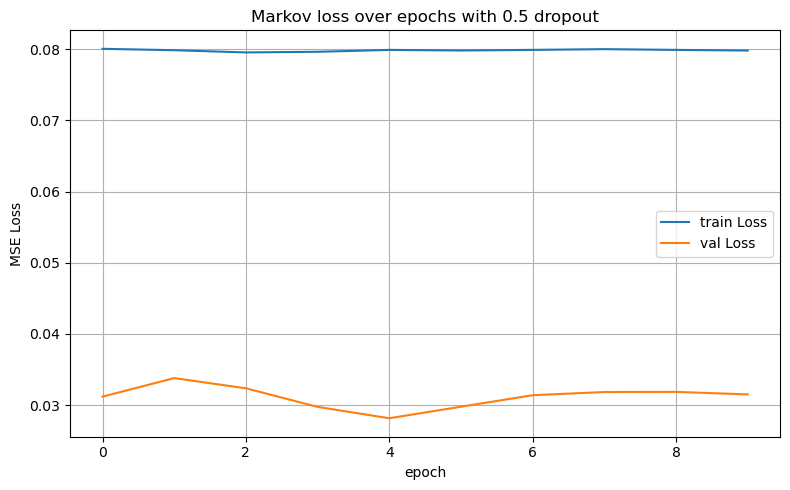

In [290]:
# plot the loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(markov_train_loss, label='train Loss')
plt.plot(markov_val_loss, label='val Loss')
plt.title('Markov loss over epochs with 0.5 dropout')
plt.xlabel('epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [291]:
# markov_0: with 0 dropout:
# markov = MarkovPredictor(input_size=input_size, output_size=output_size,dropout=dropout).to(device)
from sklearn.metrics import explained_variance_score
import time
epochs = 20
lr = 0.005
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(markov_0.parameters(), lr=lr)
markov_train_loss=[]
markov_val_loss=[]

# early stopping setting
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

patience=5

for epoch in range(epochs):
    markov_0.train()
    train_loss, y_true_train, y_pred_train = 0.0, [], []
    time1=time.time()
    for x, y, _ in markov_train_dataloader:
        
        x = x[:, -1, :].to(device) # because for markov_0 only one step is used
        y = y[:, -1, :].to(device)

        optimizer.zero_grad()
        output = markov_0(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        y_true_train.append(y.detach().cpu().numpy())
        y_pred_train.append(output.detach().cpu().numpy())

    # Validation
    markov_0.eval()
    val_loss, y_true_val, y_pred_val = 0.0, [], []

    with torch.no_grad():
        for x, y, _ in markov_val_dataloader:
            x = x[:, -1, :].to(device)
            y = y[:, -1, :].to(device)
            output = markov_0(x)
            val_loss += criterion(output, y).item()
            y_true_val.append(y.cpu().numpy())
            y_pred_val.append(output.cpu().numpy())

    # Compute EVS
    try:
        evs_val = explained_variance_score(np.concatenate(y_true_val).reshape(-1),np.concatenate(y_pred_val).reshape(-1) )
    except:
        evs_val = "N/A"

    markov_train_loss.append(train_loss / len(train_dataloader))
    markov_val_loss.append(val_loss / len(val_dataloader))
    print(f"Epoch: {epoch+1}, epoch time={time.time()-time1}s ,Train Loss = {train_loss/len(train_dataloader):.4f}, Val Loss = {val_loss/len(val_dataloader):.4f}, EVS = {evs_val}")

    # Early stopping
    if val_loss / len(val_dataloader) < best_val_loss:
        best_val_loss = val_loss / len(val_dataloader)
        epochs_no_improve = 0
        best_model_state = markov_0.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_model_state:
        markov_0.load_state_dict(best_model_state)

    

Epoch: 1, epoch time=2.2382400035858154s ,Train Loss = 0.0025, Val Loss = 0.0012, EVS = 0.9909550547599792
Epoch: 2, epoch time=2.2175498008728027s ,Train Loss = 0.0014, Val Loss = 0.0011, EVS = 0.9917099475860596
Epoch: 3, epoch time=2.057325839996338s ,Train Loss = 0.0013, Val Loss = 0.0010, EVS = 0.9926993250846863
Epoch: 4, epoch time=2.074129104614258s ,Train Loss = 0.0013, Val Loss = 0.0010, EVS = 0.9920546412467957
Epoch: 5, epoch time=2.3797662258148193s ,Train Loss = 0.0012, Val Loss = 0.0010, EVS = 0.9922471046447754
Epoch: 6, epoch time=2.2573297023773193s ,Train Loss = 0.0012, Val Loss = 0.0009, EVS = 0.9926609992980957
Epoch: 7, epoch time=2.1675240993499756s ,Train Loss = 0.0012, Val Loss = 0.0009, EVS = 0.9927322268486023
Epoch: 8, epoch time=2.296318531036377s ,Train Loss = 0.0012, Val Loss = 0.0012, EVS = 0.9904402494430542
Epoch: 9, epoch time=2.1912248134613037s ,Train Loss = 0.0012, Val Loss = 0.0008, EVS = 0.9936128854751587
Epoch: 10, epoch time=2.0281357765197754

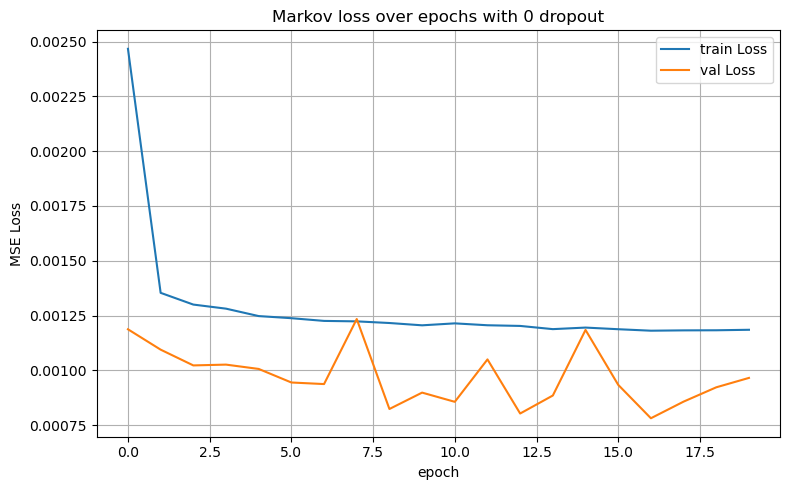

In [292]:
# plot the loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(markov_train_loss, label='train Loss')
plt.plot(markov_val_loss, label='val Loss')
plt.title('Markov loss over epochs with 0 dropout')
plt.xlabel('epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [293]:
from sklearn.metrics import explained_variance_score
import torch
import numpy as np

def train_rnn_model(model, train_dataloader, val_dataloader, epochs=20, lr=0.005, patience=5): # patience is for early stopping
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # early stopping setting
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, y_true_train, y_pred_train = 0.0, [], []
        time1 = time.time()
        for x, y , _ in train_dataloader:
            x, y = x.to(device), y.to(device)
            output_window_size = y.size()[1]
            optimizer.zero_grad()
            output = model(x) 
            output = output[:, -output_window_size:, :] # to match output size 

            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            y_true_train.append(y.detach().cpu().numpy())
            y_pred_train.append(output.detach().cpu().numpy())

        # Validation
        model.eval()
        val_loss, y_true_val, y_pred_val = 0.0, [], []

        with torch.no_grad():
            for x, y, _ in val_dataloader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                output = output[:, -output_window_size:, :] # to match output size 
                val_loss += criterion(output, y).item()
                y_true_val.append(y.cpu().numpy())
                y_pred_val.append(output.cpu().numpy())

        # Average losses
        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss = val_loss / len(val_dataloader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)


        try:
            evs_val = explained_variance_score(
                np.concatenate(y_true_val).reshape(-1),
                np.concatenate(y_pred_val).reshape(-1)
            )
        except:
            evs_val = "can not calc envs"

        print(f"Epoch {epoch+1}, epoch time={time.time()-time1:.2f}s, train Loss = {avg_train_loss:.4f}, val Loss = {avg_val_loss:.4f}, EVS = {evs_val}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

# plot function
import matplotlib.pyplot as plt
def plot_data( train_loss, val_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='train Loss')
    plt.plot(val_loss, label='val Loss')
    plt.title('loss over epochs')
    plt.xlabel('epoch')
    plt.ylabel(' Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

train gru

In [294]:
# gru: 
trained_gru, gru_train_loss, gru_val_loss = train_rnn_model(gru, train_dataloader, val_dataloader)



Epoch 1, epoch time=7.38s, train Loss = 0.0037, val Loss = 0.0013, EVS = 0.9839068055152893
Epoch 2, epoch time=7.40s, train Loss = 0.0020, val Loss = 0.0013, EVS = 0.9841604828834534
Epoch 3, epoch time=6.96s, train Loss = 0.0018, val Loss = 0.0013, EVS = 0.9847862124443054
Epoch 4, epoch time=6.65s, train Loss = 0.0017, val Loss = 0.0012, EVS = 0.9856162667274475
Epoch 5, epoch time=6.90s, train Loss = 0.0017, val Loss = 0.0012, EVS = 0.9850171804428101
Epoch 6, epoch time=6.72s, train Loss = 0.0017, val Loss = 0.0012, EVS = 0.9852370023727417
Epoch 7, epoch time=6.61s, train Loss = 0.0017, val Loss = 0.0012, EVS = 0.9852622747421265
Epoch 8, epoch time=6.54s, train Loss = 0.0016, val Loss = 0.0012, EVS = 0.9850091338157654
Epoch 9, epoch time=6.60s, train Loss = 0.0016, val Loss = 0.0012, EVS = 0.9851478338241577
Early stopping at epoch 9


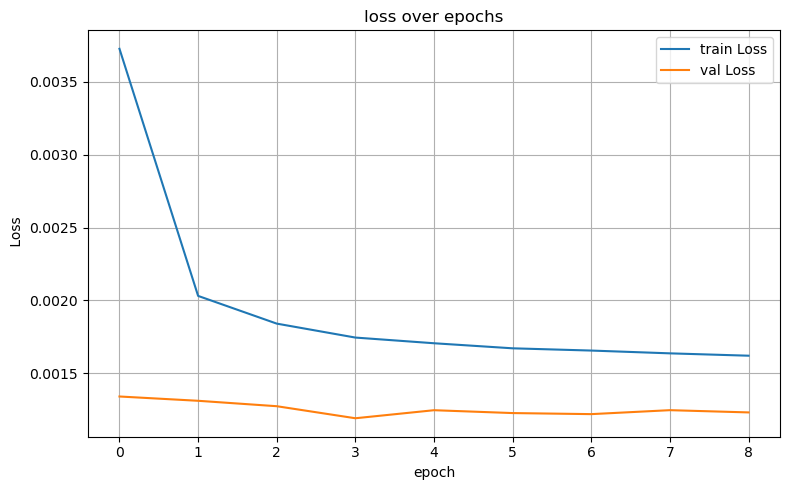

In [295]:
plot_data( gru_train_loss, gru_val_loss)

train bigru

In [296]:
# bigru
trained_bigru, bigru_train_loss, bigru_val_loss = train_rnn_model(bigru, train_dataloader, val_dataloader)


Epoch 1, epoch time=12.30s, train Loss = 0.0026, val Loss = 0.0010, EVS = 0.9878440499305725
Epoch 2, epoch time=14.01s, train Loss = 0.0014, val Loss = 0.0009, EVS = 0.9887254238128662
Epoch 3, epoch time=13.54s, train Loss = 0.0013, val Loss = 0.0009, EVS = 0.9893587827682495
Epoch 4, epoch time=12.94s, train Loss = 0.0012, val Loss = 0.0009, EVS = 0.9893377423286438
Epoch 5, epoch time=11.91s, train Loss = 0.0012, val Loss = 0.0009, EVS = 0.9894940257072449
Epoch 6, epoch time=12.15s, train Loss = 0.0012, val Loss = 0.0008, EVS = 0.9897615313529968
Epoch 7, epoch time=11.86s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.9899892210960388
Epoch 8, epoch time=12.28s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.9902924299240112
Epoch 9, epoch time=12.55s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.9900466799736023
Epoch 10, epoch time=11.86s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.9903713464736938
Epoch 11, epoch time=11.91s, train Loss = 0.0011, val Loss = 0.0008, 

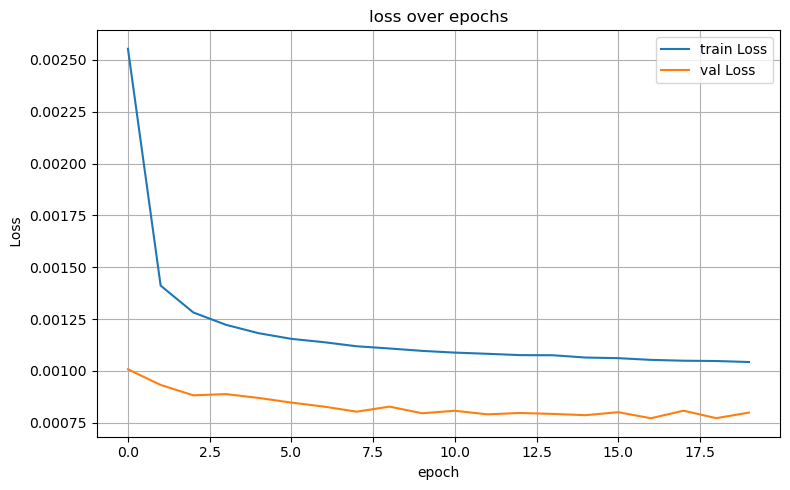

In [297]:
plot_data( bigru_train_loss, bigru_val_loss)

train lstm

In [298]:
# lstm
trained_lstm, lstm_train_loss, lstm_val_loss = train_rnn_model(lstm,train_dataloader, val_dataloader)


Epoch 1, epoch time=4.04s, train Loss = 0.0046, val Loss = 0.0022, EVS = 0.9739616513252258
Epoch 2, epoch time=4.09s, train Loss = 0.0024, val Loss = 0.0016, EVS = 0.9800892472267151
Epoch 3, epoch time=4.07s, train Loss = 0.0020, val Loss = 0.0014, EVS = 0.9832157492637634
Epoch 4, epoch time=3.93s, train Loss = 0.0018, val Loss = 0.0013, EVS = 0.9839358329772949
Epoch 5, epoch time=3.89s, train Loss = 0.0017, val Loss = 0.0013, EVS = 0.9845216870307922
Epoch 6, epoch time=3.86s, train Loss = 0.0017, val Loss = 0.0012, EVS = 0.9852991104125977
Epoch 7, epoch time=3.93s, train Loss = 0.0016, val Loss = 0.0012, EVS = 0.9853772521018982
Epoch 8, epoch time=3.87s, train Loss = 0.0016, val Loss = 0.0012, EVS = 0.985440731048584
Epoch 9, epoch time=3.92s, train Loss = 0.0016, val Loss = 0.0013, EVS = 0.9849187135696411
Epoch 10, epoch time=3.86s, train Loss = 0.0016, val Loss = 0.0012, EVS = 0.9856265187263489
Epoch 11, epoch time=3.85s, train Loss = 0.0015, val Loss = 0.0012, EVS = 0.9852

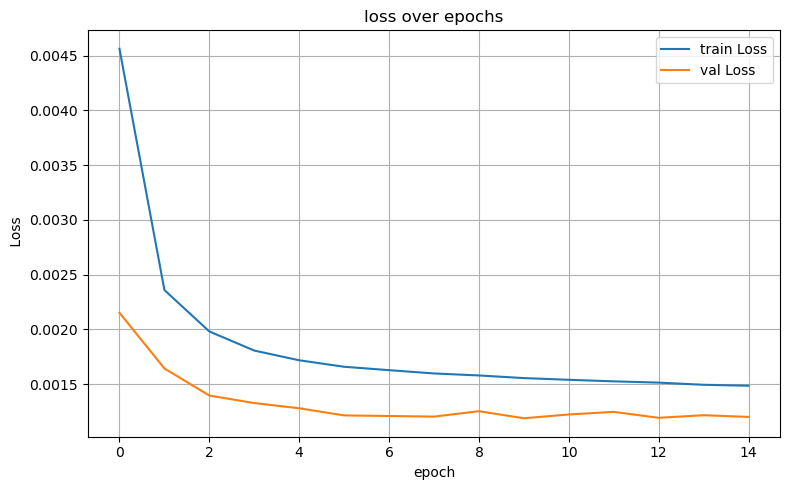

In [299]:
plot_data( lstm_train_loss, lstm_val_loss)

train bilstm

In [300]:
# bilstm
trained_bilstm, bilstm_train_loss, bilstm_val_loss = train_rnn_model(bilstm, train_dataloader, val_dataloader)

Epoch 1, epoch time=6.45s, train Loss = 0.0030, val Loss = 0.0011, EVS = 0.9863484501838684
Epoch 2, epoch time=6.54s, train Loss = 0.0015, val Loss = 0.0009, EVS = 0.9886354804039001
Epoch 3, epoch time=6.54s, train Loss = 0.0013, val Loss = 0.0010, EVS = 0.9876829981803894
Epoch 4, epoch time=6.13s, train Loss = 0.0013, val Loss = 0.0009, EVS = 0.9889414310455322
Epoch 5, epoch time=6.19s, train Loss = 0.0012, val Loss = 0.0009, EVS = 0.989387571811676
Epoch 6, epoch time=6.24s, train Loss = 0.0012, val Loss = 0.0009, EVS = 0.9894183278083801
Epoch 7, epoch time=6.30s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.9898839592933655
Epoch 8, epoch time=6.35s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.9898731112480164
Epoch 9, epoch time=6.50s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.989993155002594
Epoch 10, epoch time=6.27s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.990379810333252
Epoch 11, epoch time=6.17s, train Loss = 0.0011, val Loss = 0.0008, EVS = 0.990143

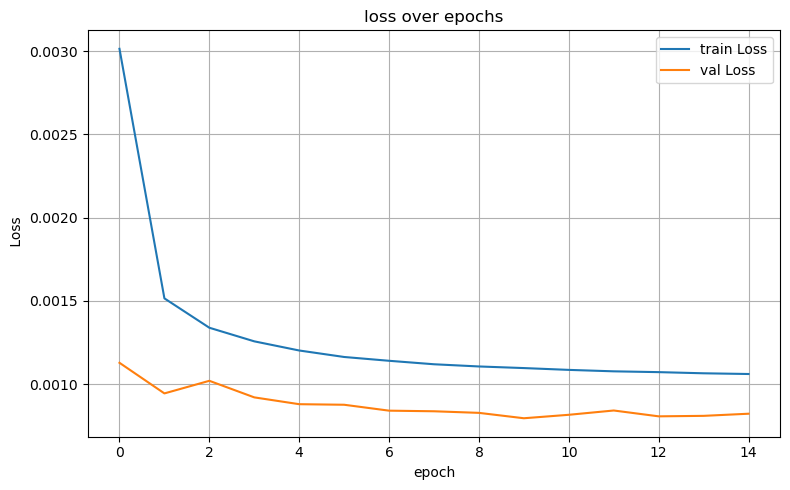

In [301]:
plot_data( bilstm_train_loss, bilstm_val_loss)

## 2-4-4:

In [302]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial.distance import cosine
import numpy as np

def evaluate_model(model, test_loader):
    model.eval()
    device = next(model.parameters()).device
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for x, y, _ in test_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            output = output[:, -y.shape[1]:, :]  # align shapes if needed
            y_true_all.append(y.cpu().numpy())
            y_pred_all.append(output.cpu().numpy())

    y_true = np.concatenate(y_true_all, axis=0).reshape(-1, y.shape[-1])
    y_pred = np.concatenate(y_pred_all, axis=0).reshape(-1, y.shape[-1])

    # Calculate metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cos_dist = cosine(y_true.flatten(), y_pred.flatten())
    np.set_printoptions(legacy='1.25')
    return {'MSE': np.round(mse,4), 'MAE': np.round(mae,4), 'R2': np.round(r2,4), 'Cosine Distance': np.round(cos_dist,4)}

def markov_evaluate_model(model, test_loader):
    model.eval()
    device = next(model.parameters()).device
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for x, y, _ in test_loader:
            x, y = x.to(device), y.to(device)
            x = x[:, -1, :].to(device)
            y = y[:, -1, :].to(device)
            output = model(x)
            # print(output.size())
            # print(y.size())
            # output = output
            y_true_all.append(y.cpu().numpy())
            y_pred_all.append(output.cpu().numpy())

    y_true = np.concatenate(y_true_all, axis=0).reshape(-1)
    y_pred = np.concatenate(y_pred_all, axis=0).reshape(-1)

    # Calculate metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cos_dist = cosine(y_true.flatten(), y_pred.flatten())
    np.set_printoptions(legacy='1.25')
    return {'MSE': np.round(mse,4), 'MAE': np.round(mae,4), 'R2': np.round(r2,4), 'Cosine Distance': np.round(cos_dist,4)}

In [303]:
metrics_gru = evaluate_model(trained_gru, test_dataloader)
metrics_bigru = evaluate_model(trained_bigru, test_dataloader)
metrics_lstm = evaluate_model(trained_lstm, test_dataloader)
metrics_bilstm = evaluate_model(trained_bilstm, test_dataloader)
metrics_markov = markov_evaluate_model(markov, markov_test_dataloader)

In [304]:
print("GRU:", metrics_gru)
print("BiGRU:", metrics_bigru)
print("LSTM:", metrics_lstm)
print("BiLSTM:", metrics_bilstm)
print("Markov:", metrics_markov)

GRU: {'MSE': 0.002, 'MAE': 0.0241, 'R2': 0.6159, 'Cosine Distance': 0.0052}
BiGRU: {'MSE': 0.0014, 'MAE': 0.0178, 'R2': 0.7703, 'Cosine Distance': 0.0036}
LSTM: {'MSE': 0.0021, 'MAE': 0.0247, 'R2': 0.604, 'Cosine Distance': 0.0055}
BiLSTM: {'MSE': 0.0014, 'MAE': 0.0193, 'R2': 0.7332, 'Cosine Distance': 0.0037}
Markov: {'MSE': 0.0238, 'MAE': 0.1269, 'R2': 0.7147, 'Cosine Distance': 0.0619}


## 2-5:

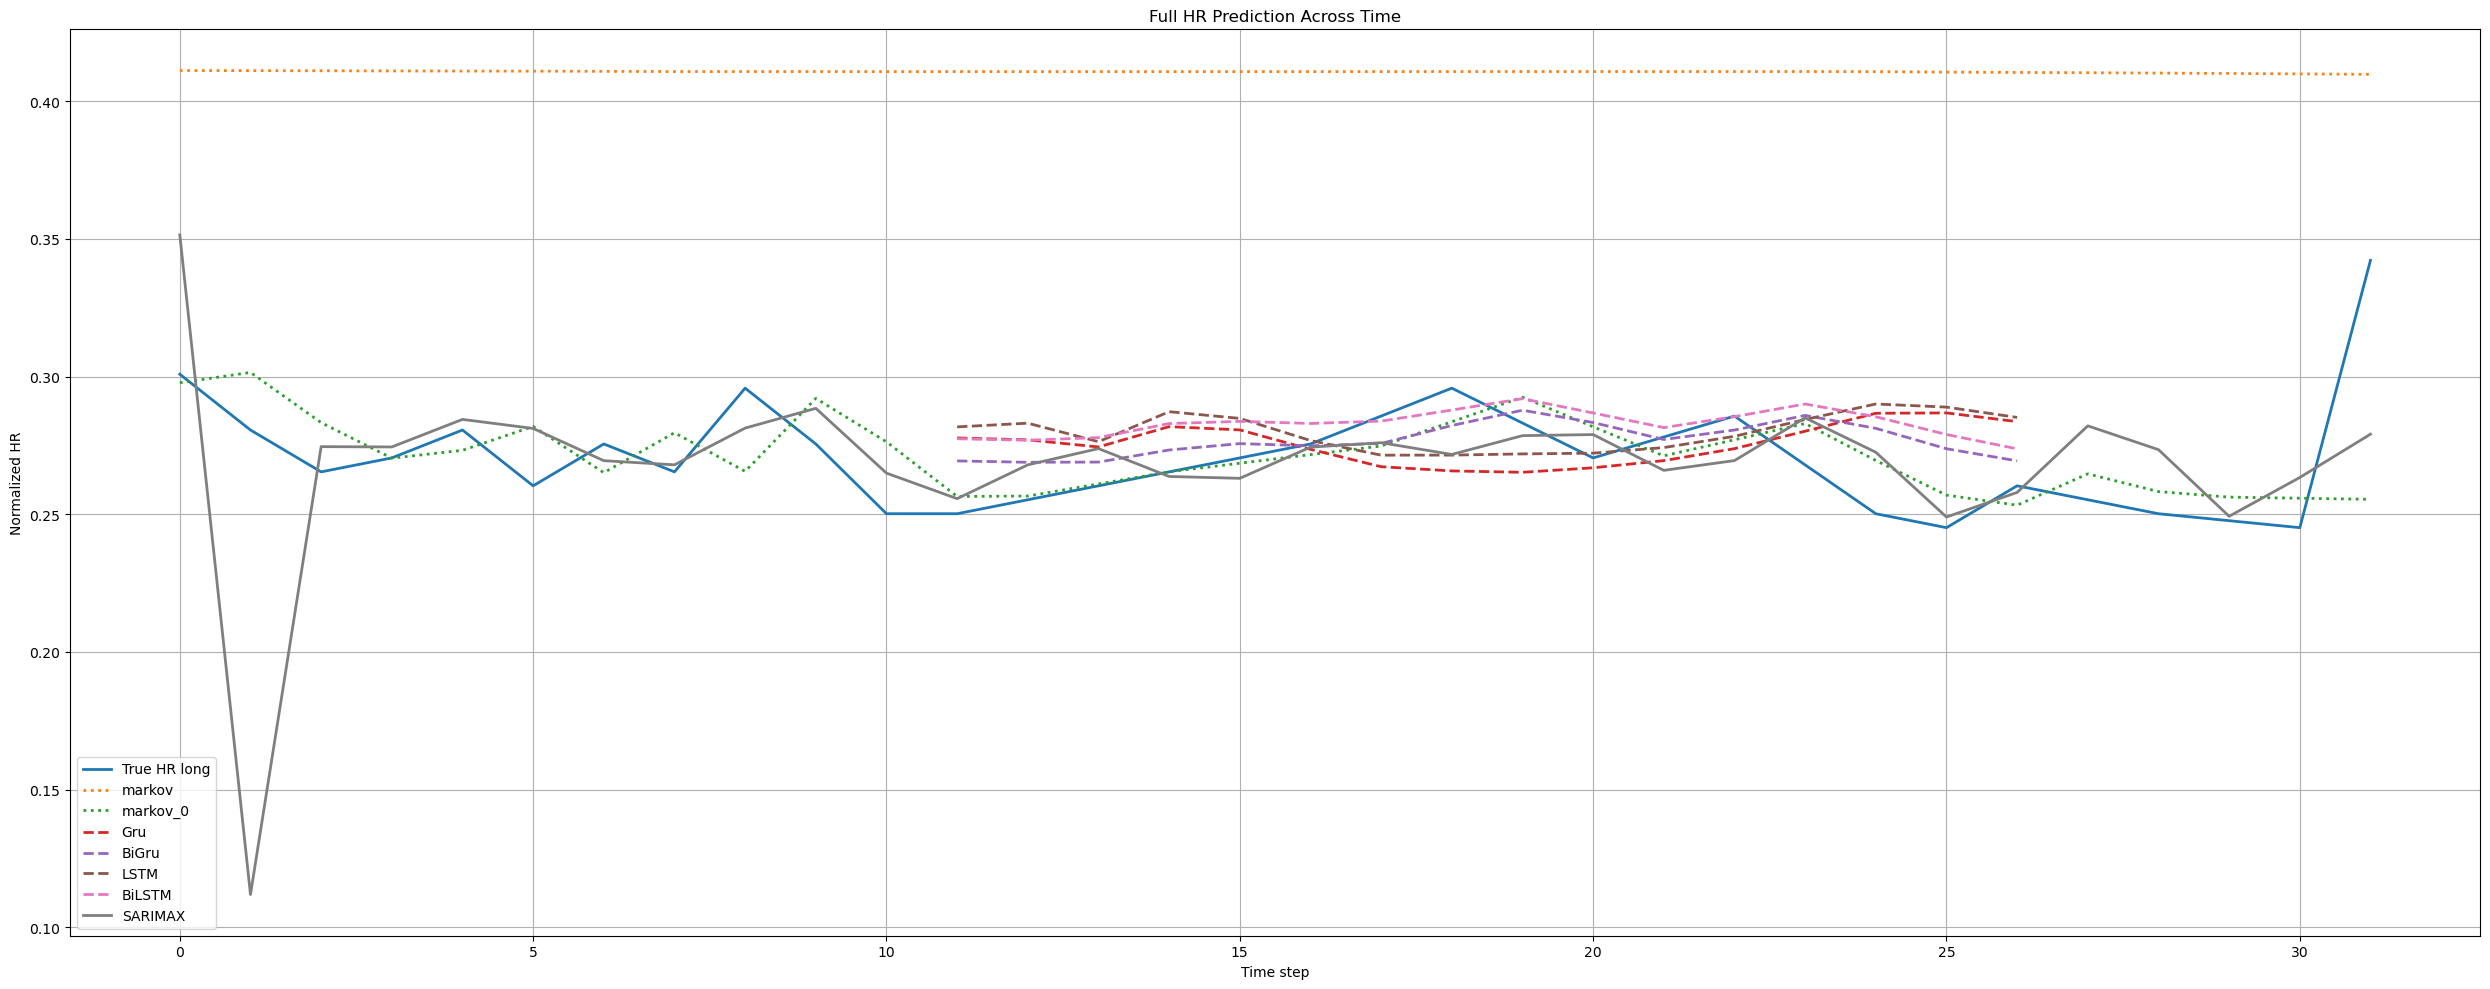

In [305]:
train_dataloader1= DataLoader(train_dataset, batch_size=1, shuffle=True)
val_dataloader1 = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_dataloader1 =DataLoader(test_dataset, batch_size=1, shuffle=False)

markov_train_dataloader1 = DataLoader(markov_train_dataset, batch_size=1, shuffle=True)
markov_val_dataloader1 = DataLoader(markov_val_dataset, batch_size=1, shuffle=False)
markov_test_dataloader1 =DataLoader(markov_test_dataset, batch_size=1, shuffle=False)

def calc_output(model, test_loader, patient_id = patient_id):
    hr_index = feature_columns.index("HR")
    model.eval()
    device = next(model.parameters()).device
    y_true_all, y_pred_all = [], []
    # loop_counter =0
    with torch.no_grad():
        for x, y, pid in test_loader:
            if pid[0].item() == patient_id:
                x, y = x.to(device), y.to(device)
                output = model(x)

                output = output[:, -y.shape[1]:, hr_index]  # align shapes if needed
                y=y[:,:,hr_index]
                # print((y.cpu().numpy().flatten()))
                y_true_all.append(y.cpu().numpy().flatten()[0])
                y_pred_all.append(output.cpu().numpy().flatten()[0])

    # y_true = np.concatenate(y_true_all, axis=0)
    # y_pred = np.concatenate(y_pred_all, axis=0)
    return y_true_all, y_pred_all

def markov_calc_output(model, test_loader, patient_id = patient_id):
    hr_index = feature_columns.index("HR")
    model.eval()
    device = next(model.parameters()).device
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for x, y, pid in test_loader:
            if pid[0].item() == patient_id:
                x, y = x.to(device), y.to(device)
                x = x[:, -1, :].to(device)
                y = y[:, -1, :].to(device)
                output = model(x)
                output = output[:, hr_index] 
                y=y[:,hr_index]
                # output = output
                y_true_all.append(y.cpu().numpy())
                y_pred_all.append(output.cpu().numpy())

    # y_true_all = np.concatenate(y_true_all, axis=0).reshape(-1, y.shape[-1])
    # y_pred_all = np.concatenate(y_pred_all, axis=0).reshape(-1, y.shape[-1])

    return y_true_all, y_pred_all

plt.figure(figsize=(25, 10))
# output od markovs:
y_true_markov, y_pred_markov = markov_calc_output(markov, markov_test_dataloader1, patient_id=patient_id)
x_models_markov=np.arange(0, len(y_pred_markov))
plt.plot(x_models_markov,y_true_markov, label="True HR long", linewidth=2)
plt.plot(x_models_markov,y_pred_markov, label="markov", linewidth=2, linestyle=':')

y_true_markov_0, y_pred_markov_0= markov_calc_output(markov_0, markov_test_dataloader1, patient_id=patient_id)
x_models_markov=np.arange(0, len(y_pred_markov_0))
plt.plot(x_models_markov,y_pred_markov_0, label="markov_0", linewidth=2, linestyle=':')


# outputs of models: except markovs:


y_true_gru, y_pred_gru = calc_output(trained_gru, test_dataloader1, patient_id=patient_id)
x_models =  np.arange(W_input-1, W_input+len(y_pred_gru)-1,1)
# plt.plot(x_models,y_true, label="True HR", linewidth=2)
plt.plot(x_models,y_pred_gru, label="Gru", linewidth=2, linestyle='--')

y_true_bigru, y_pred_bigru = calc_output(trained_bigru, test_dataloader1, patient_id=patient_id)
plt.plot(x_models,y_pred_bigru, label="BiGru", linewidth=2, linestyle='--')

y_true_lstm, y_pred_lstm = calc_output(trained_lstm, test_dataloader1, patient_id=patient_id)
plt.plot(x_models,y_pred_lstm, label="LSTM", linewidth=2,linestyle='--')

y_true_bilstm, y_pred_bilstm = calc_output(trained_bilstm, test_dataloader1, patient_id=patient_id)
plt.plot(x_models,y_pred_bilstm, label="BiLSTM", linewidth=2, linestyle='--')



# SARIMAX:

hr_index = feature_columns.index("HR")
sarimax_scaler_max =feature_scaler.data_max_[hr_index]
sarimax_scaler_min =feature_scaler.data_min_[hr_index]

y_pred = predicted_HR.values
y_pred_sarimax = (y_pred-sarimax_scaler_min)/(sarimax_scaler_max-sarimax_scaler_min)

plt.plot(x_models_markov,y_pred_sarimax[1:], label="SARIMAX", linewidth=2)

plt.title("Full HR Prediction Across Time")
plt.xlabel("Time step")
plt.ylabel("Normalized HR")
# plt.ylim([0,1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [306]:
def calc_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

    cos_dist = cosine(y_true.reshape(-1), y_pred.reshape(-1))
    np.set_printoptions(legacy='1.25')
    return {'MSE': np.round(mse,4), 'MAE': np.round(mae,4), 'R2': np.round(r2,4), 'Cosine Distance': np.round(cos_dist,4)}


In [307]:
# metrics over the test data:
gru_metrics = calc_metrics(np.array(y_true_gru), np.array(y_pred_gru))
bigru_metrics = calc_metrics(np.array(y_true_bigru), np.array(y_pred_bigru))
lstm_metrics = calc_metrics(np.array(y_true_lstm), np.array(y_pred_lstm))
bilstm_metrics = calc_metrics(np.array(y_true_bilstm), np.array(y_pred_bilstm))
markov_metrics = calc_metrics(np.array(y_true_markov), np.array(y_pred_markov))
markov_0_metrics = calc_metrics(np.array(y_true_markov_0), np.array(y_pred_markov_0))
SARIMAX_metrics = calc_metrics(np.array(y_true_markov), np.array(y_pred_sarimax[1:]))

In [308]:
print("GRU:", gru_metrics)
print("BiGRU:", bigru_metrics)
print("LSTM:", lstm_metrics)
print("BiLSTM:", bilstm_metrics)
print("Markov:", markov_metrics)
print("Markov_0: ", markov_0_metrics)
print("SARIMAX", SARIMAX_metrics)

GRU: {'MSE': 0.0005, 'MAE': 0.0185, 'R2': -1.2769, 'Cosine Distance': 0.0028}
BiGRU: {'MSE': 0.0002, 'MAE': 0.0118, 'R2': -0.0532, 'Cosine Distance': 0.001}
LSTM: {'MSE': 0.0005, 'MAE': 0.0188, 'R2': -1.5056, 'Cosine Distance': 0.0026}
BiLSTM: {'MSE': 0.0003, 'MAE': 0.0155, 'R2': -0.7123, 'Cosine Distance': 0.001}
Markov: {'MSE': 0.02, 'MAE': 0.14, 'R2': -49.7333, 'Cosine Distance': 0.0027}
Markov_0:  {'MSE': 0.0004, 'MAE': 0.0131, 'R2': -0.0139, 'Cosine Distance': 0.0027}
SARIMAX {'MSE': 0.0013, 'MAE': 0.0189, 'R2': -2.1862, 'Cosine Distance': 0.0085}


HR for a train data:

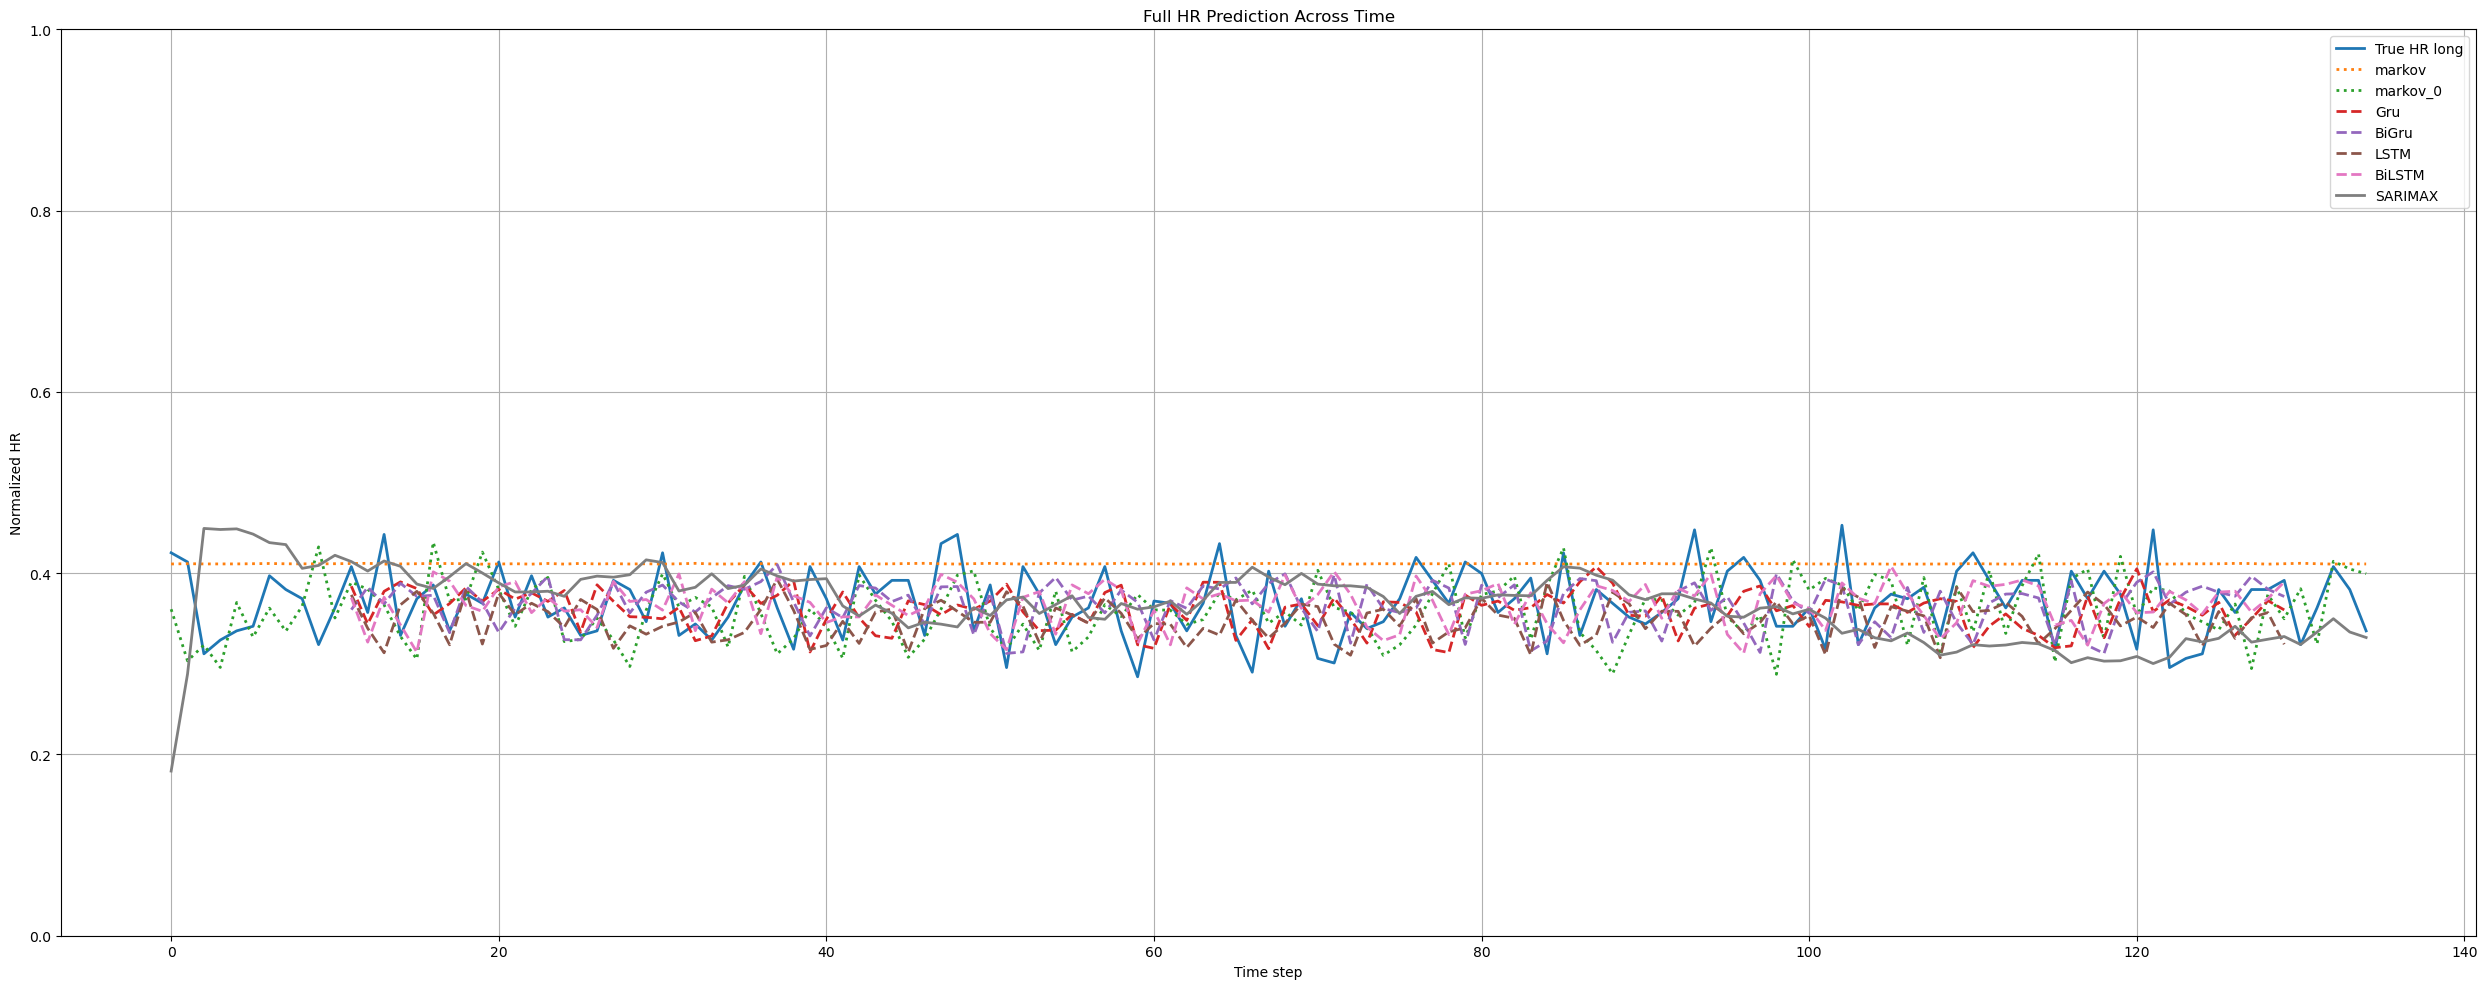

In [309]:
plt.figure(figsize=(25, 10))
# output od markovs:
y_true_markov, y_pred_markov = markov_calc_output(markov, markov_train_dataloader1, patient_id=patient_id)
x_models_markov=np.arange(0, len(y_pred_markov))
plt.plot(x_models_markov,y_true_markov, label="True HR long", linewidth=2)
plt.plot(x_models_markov,y_pred_markov, label="markov", linewidth=2, linestyle=':')

y_true_markov_0, y_pred_markov_0= markov_calc_output(markov_0, markov_train_dataloader1, patient_id=patient_id)
x_models_markov=np.arange(0, len(y_pred_markov_0))
plt.plot(x_models_markov,y_pred_markov_0, label="markov_0", linewidth=2, linestyle=':')


# outputs of models: except markovs:


y_true_gru, y_pred_gru = calc_output(trained_gru, train_dataloader1, patient_id=patient_id)
x_models =  np.arange(W_input-1, W_input+len(y_pred_gru)-1,1)
# plt.plot(x_models,y_true, label="True HR", linewidth=2)
plt.plot(x_models,y_pred_gru, label="Gru", linewidth=2, linestyle='--')

y_true_bigru, y_pred_bigru = calc_output(trained_bigru, train_dataloader1, patient_id=patient_id)
plt.plot(x_models,y_pred_bigru, label="BiGru", linewidth=2, linestyle='--')

y_true_lstm, y_pred_lstm = calc_output(trained_lstm, train_dataloader1, patient_id=patient_id)
plt.plot(x_models,y_pred_lstm, label="LSTM", linewidth=2,linestyle='--')

y_true_bilstm, y_pred_bilstm = calc_output(trained_bilstm, train_dataloader1, patient_id=patient_id)
plt.plot(x_models,y_pred_bilstm, label="BiLSTM", linewidth=2, linestyle='--')



# SARIMAX:

hr_index = feature_columns.index("HR")
sarimax_scaler_max =feature_scaler.data_max_[hr_index]
sarimax_scaler_min =feature_scaler.data_min_[hr_index]

y_pred = predicted_HR_train.values
y_pred_sarimax = (y_pred-sarimax_scaler_min)/(sarimax_scaler_max-sarimax_scaler_min)

plt.plot(x_models_markov,y_pred_sarimax[1:], label="SARIMAX", linewidth=2)

plt.title("Full HR Prediction Across Time")
plt.xlabel("Time step")
plt.ylabel("Normalized HR")
plt.ylim([0,1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2-6-1:

In [310]:
# define new dataset:
class MyNewDataset(Dataset):
    def __init__(self, grouped_df: pd.DataFrame, input_window, output_window, feature_cols=None, label_cols = None):
        self.input_window = input_window
        self.output_window = output_window
        self.samples = []

        if feature_cols is None:
            feature_cols = [col for col in grouped_df.obj.columns if col not in ['Patient_ID', 'Hour']]
        if label_cols is None:
            label_cols = feature_cols

        for patient_id, group in grouped_df:
            group = group.sort_values('Hour')
            x_seq = group[feature_cols].to_numpy(dtype=np.float32)
            y_seq = group[label_cols].to_numpy(dtype=np.float32) 
            T = x_seq.shape[0]

            if T < input_window + output_window:
                continue

            for t in range(T - input_window - output_window + 1):
                x_win = x_seq[t:t+input_window]
                y_win = y_seq[t+input_window:t+input_window+output_window]

                x_mean, x_var = x_win.mean(axis=0), x_win.var(axis=0)
                y_mean, y_var = y_win.mean(axis=0), y_win.var(axis=0)

                x_summary = np.concatenate([x_mean, x_var])
                y_summary = np.concatenate([y_mean, y_var])

                self.samples.append((x_summary, y_summary, patient_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y, pid = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32), pid
    



In [311]:
feature_columns = lowest_20_features
W_input_2 = 12
W_output_2 = 6
train_dataset_2 = MyNewDataset(train_scaled, input_window=W_input_2, output_window=W_output_2, feature_cols=feature_columns)
test_dataset_2 = MyNewDataset(test_scaled, input_window=W_input_2, output_window=W_output_2, feature_cols=feature_columns)
val_dataset_2 = MyNewDataset(val_scaled, input_window=W_input_2, output_window=W_output_2, feature_cols=feature_columns)


# test dataset:
x, y , _= train_dataset_2[0]
print("input shape:", x.shape) 
print("output shape:", y.shape) 
print("inout :", x) 
print("output:", y) 

batch_size = 16
lr = 0.005



input shape: torch.Size([40])
output shape: torch.Size([40])
inout : tensor([4.1320e-02, 2.0956e-01, 4.4958e-02, 3.0778e-01, 1.9428e-03, 3.3666e-01,
        2.1304e-01, 2.6170e-01, 3.4143e-02, 2.3606e-02, 2.4139e-01, 9.9573e-01,
        3.8531e-01, 6.7498e-01, 5.9487e-01, 9.8337e-01, 2.2286e-01, 2.8029e-02,
        4.2099e-01, 3.5162e-01, 1.6216e-09, 3.7290e-05, 2.8858e-07, 5.2580e-03,
        5.6090e-10, 1.3329e-06, 5.3109e-05, 8.8818e-16, 6.9817e-09, 6.6115e-09,
        3.1161e-05, 3.6526e-05, 8.0133e-04, 1.0909e-03, 1.2445e-03, 5.1400e-07,
        1.4781e-06, 7.9349e-07, 8.7192e-05, 6.1931e-06])
output: tensor([4.1425e-02, 2.2934e-01, 4.3557e-02, 2.4889e-01, 2.0046e-03, 3.4044e-01,
        2.3609e-01, 2.6170e-01, 3.3925e-02, 2.3818e-02, 2.1748e-01, 9.7863e-01,
        4.3766e-01, 5.9536e-01, 6.1237e-01, 9.8293e-01, 2.2222e-01, 2.5707e-02,
        4.4534e-01, 3.5976e-01, 3.9690e-10, 2.0622e-05, 7.0633e-08, 3.9506e-05,
        1.3728e-10, 6.4046e-07, 2.2589e-05, 0.0000e+00, 1.7088e-09

In [312]:
class NewLSTMModel(nn.Module):
    def __init__(self, input_size=20*2, hidden_size=128, output_size=20*2, dropout=0.5):
        super(NewLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        # self.dropout2 = nn.Dropout(dropout)
        # self.sigmoid = nn.Sigmoid()
        # self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)            
        out = self.dropout(out)
        out = self.fc(out)
        # out = self.dropout2(out)
        # out = self.sigmoid(out)
        # out = self.fc2(out)                
        return out
    
lstm_2 = NewLSTMModel(input_size=input_size*2, hidden_size=hidden_size, output_size=output_size*2, dropout=dropout).to(device)
train_dataloader_2 = DataLoader(train_dataset_2, batch_size=batch_size, shuffle=True)
val_dataloader_2 = DataLoader(val_dataset_2, batch_size=batch_size, shuffle=False)
test_dataloader_2 =DataLoader(test_dataset_2, batch_size=batch_size, shuffle=False)

In [313]:
def train_rnn_model_2(model, train_dataloader, val_dataloader, epochs=20, lr=0.005, patience=5): # patience is for early stopping
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # early stopping setting
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, y_true_train, y_pred_train = 0.0, [], []
        time1 = time.time()
        for x, y , _ in train_dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x) 

            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            y_true_train.append(y.detach().cpu().numpy())
            y_pred_train.append(output.detach().cpu().numpy())

        # Validation
        model.eval()
        val_loss, y_true_val, y_pred_val = 0.0, [], []

        with torch.no_grad():
            for x, y, _ in val_dataloader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                val_loss += criterion(output, y).item()
                y_true_val.append(y.cpu().numpy())
                y_pred_val.append(output.cpu().numpy())
            # r2 = r2_score(y_true_val, y_pred_val)

        # Average losses
        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss = val_loss / len(val_dataloader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)


        try:
            evs_val = explained_variance_score(
                np.concatenate(y_true_val).reshape(-1),
                np.concatenate(y_pred_val).reshape(-1)
            )
        except:
            evs_val = "can not calc envs"

        print(f"Epoch {epoch+1}, epoch time={time.time()-time1:.2f}s, train Loss = {avg_train_loss:.4f}, val Loss = {avg_val_loss:.4f}, EVS = {evs_val:.2f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

In [314]:
trained_lstm_2, lstm_2_train_loss, lstm_2_val_loss = train_rnn_model_2(lstm_2, train_dataloader_2, val_dataloader_2)

Epoch 1, epoch time=2.99s, train Loss = 0.0023, val Loss = 0.0007, EVS = 0.99
Epoch 2, epoch time=2.86s, train Loss = 0.0009, val Loss = 0.0006, EVS = 0.99
Epoch 3, epoch time=2.88s, train Loss = 0.0009, val Loss = 0.0006, EVS = 0.99
Epoch 4, epoch time=2.81s, train Loss = 0.0009, val Loss = 0.0006, EVS = 0.99
Epoch 5, epoch time=2.93s, train Loss = 0.0009, val Loss = 0.0005, EVS = 0.99
Epoch 6, epoch time=2.91s, train Loss = 0.0009, val Loss = 0.0006, EVS = 0.99
Epoch 7, epoch time=2.73s, train Loss = 0.0009, val Loss = 0.0006, EVS = 0.99
Epoch 8, epoch time=2.83s, train Loss = 0.0009, val Loss = 0.0005, EVS = 0.99
Epoch 9, epoch time=2.85s, train Loss = 0.0008, val Loss = 0.0005, EVS = 0.99
Epoch 10, epoch time=2.79s, train Loss = 0.0008, val Loss = 0.0005, EVS = 0.99
Epoch 11, epoch time=2.71s, train Loss = 0.0008, val Loss = 0.0006, EVS = 0.99
Epoch 12, epoch time=2.72s, train Loss = 0.0008, val Loss = 0.0005, EVS = 0.99
Epoch 13, epoch time=2.73s, train Loss = 0.0008, val Loss = 0

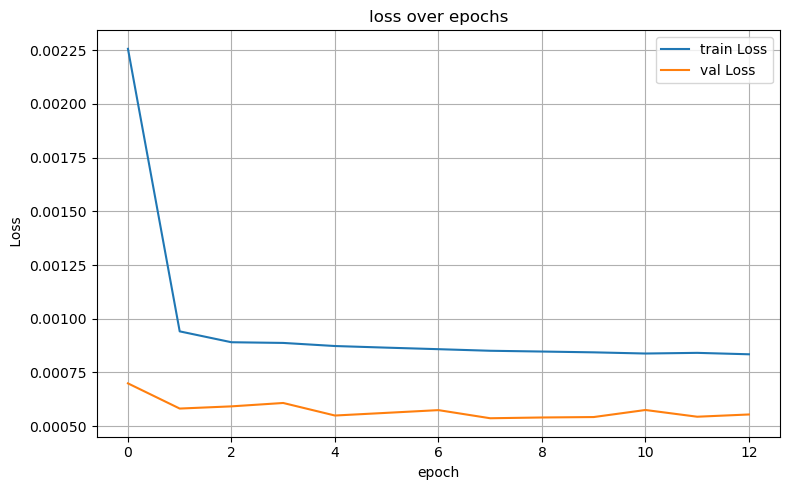

In [315]:
plot_data( lstm_2_train_loss, lstm_2_val_loss)

In [316]:
def evaluate_model_2(model, test_loader):
    model.eval()
    device = next(model.parameters()).device
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for x, y, _ in test_loader:
            x, y = x.to(device), y.to(device)
            
            output = model(x)
            # output = output
            # print(output.size())
            
            y_true_all.append(y.cpu().numpy())
            y_pred_all.append(output.cpu().numpy())

    y_true = np.concatenate(y_true_all, axis=0).reshape(-1)
    y_pred = np.concatenate(y_pred_all, axis=0).reshape(-1)
    # Calculate metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cos_dist = cosine(y_true.flatten(), y_pred.flatten())
    np.set_printoptions(legacy='1.25')
    return {'MSE': np.round(mse,4), 'MAE': np.round(mae,4), 'R2': np.round(r2,4), 'Cosine Distance': np.round(cos_dist,4)}

metrics_lstm_2 = evaluate_model_2(trained_lstm_2, test_dataloader_2)

print("LSTM2:", metrics_lstm_2)

LSTM2: {'MSE': 0.0007, 'MAE': 0.0121, 'R2': 0.9897, 'Cosine Distance': 0.0037}


## 2-6-3:

In [317]:
# extract data:
# lstm_2
train_dataloader_2_1 = DataLoader(train_dataset_2, batch_size=1, shuffle=True)
val_dataloader_2_1 = DataLoader(val_dataset_2, batch_size=1, shuffle=False)
test_dataloader_2_1 =DataLoader(test_dataset_2, batch_size=1, shuffle=False)

def add_laplace_noise_tensor(tensor, scale=0.1):
    noise = torch.distributions.Laplace(loc=0.0, scale=scale).sample(tensor.size())
    return tensor + noise

def calc_output_2(model, test_loader, patient_id = patient_id):
    hr_index = feature_columns.index("HR")
    model.eval()
    device = next(model.parameters()).device
    y_true_mean, y_true_var, y_pred_mean, y_pred_var = [], [], [], []

    with torch.no_grad():
        for x, y, pid in test_loader:
            if pid[0].item() == patient_id:
                x, y = x.to(device), y.to(device)
                
                x = add_laplace_noise_tensor(x)
                x_mean = x[0,hr_index]
                x_var = x[0, hr_index+20]
                y_mean = y[0, hr_index]
                y_var = y[0,hr_index+20]

                output = model(x)
                y_pred_m = output[0,hr_index]
                y_pred_v = output[0,hr_index+20]

                # output = output
                # print(output.size())
                # print(x.size())

                y_true_mean.append(y_mean.cpu().item())
                y_true_var.append(y_var.cpu().item())

                # print(y_true_mean)
                y_pred_mean.append(y_pred_m.cpu().item())
                y_pred_var.append(y_pred_v.cpu().item())

                                                        
    y_true_mean_all = y_true_mean
    y_true_var_all = y_true_var
    y_pred_mean_all = y_pred_mean
    y_pred_var_all =y_pred_var

    return  y_true_mean_all, y_true_var_all, y_pred_mean_all, y_pred_var_all

y_true_mean_all, y_true_var_all, y_pred_mean_lstm_2, y_pred_var_lstm_2 = calc_output_2(lstm_2, test_dataloader_2_1 , patient_id= patient_id)


# lstm:
def calc_mean_var_lstm(model, test_loader, patient_id = patient_id):
    hr_index = feature_columns.index("HR")
    model.eval()
    device = next(model.parameters()).device
    y_true_mean, y_true_var, y_pred_mean, y_pred_var = [], [], [], []
    # loop_counter =0
    with torch.no_grad():
        for x, y, pid in test_loader:
            if pid[0].item() == patient_id:
                x, y = x.to(device), y.to(device)
                x = add_laplace_noise_tensor(x)
                output = model(x)
                # print(output.size())
                output = output[:, -y.shape[1]:, hr_index]  # align shapes if needed
                y=y[:,:,hr_index]

                y_pred_m = output.mean()
                y_pred_v = output.var()
                # print((y.cpu().numpy().flatten()))
                y_pred_mean.append(y_pred_m.cpu().item())
                y_pred_var.append(y_pred_v.cpu().item())

    # y_true = np.concatenate(y_true_all, axis=0)
    # y_pred = np.concatenate(y_pred_all, axis=0)
    return y_pred_mean, y_pred_var

y_pred_mean_bilstm, y_pred_var_bilstm = calc_mean_var_lstm(trained_bilstm, test_dataloader1, patient_id=patient_id)



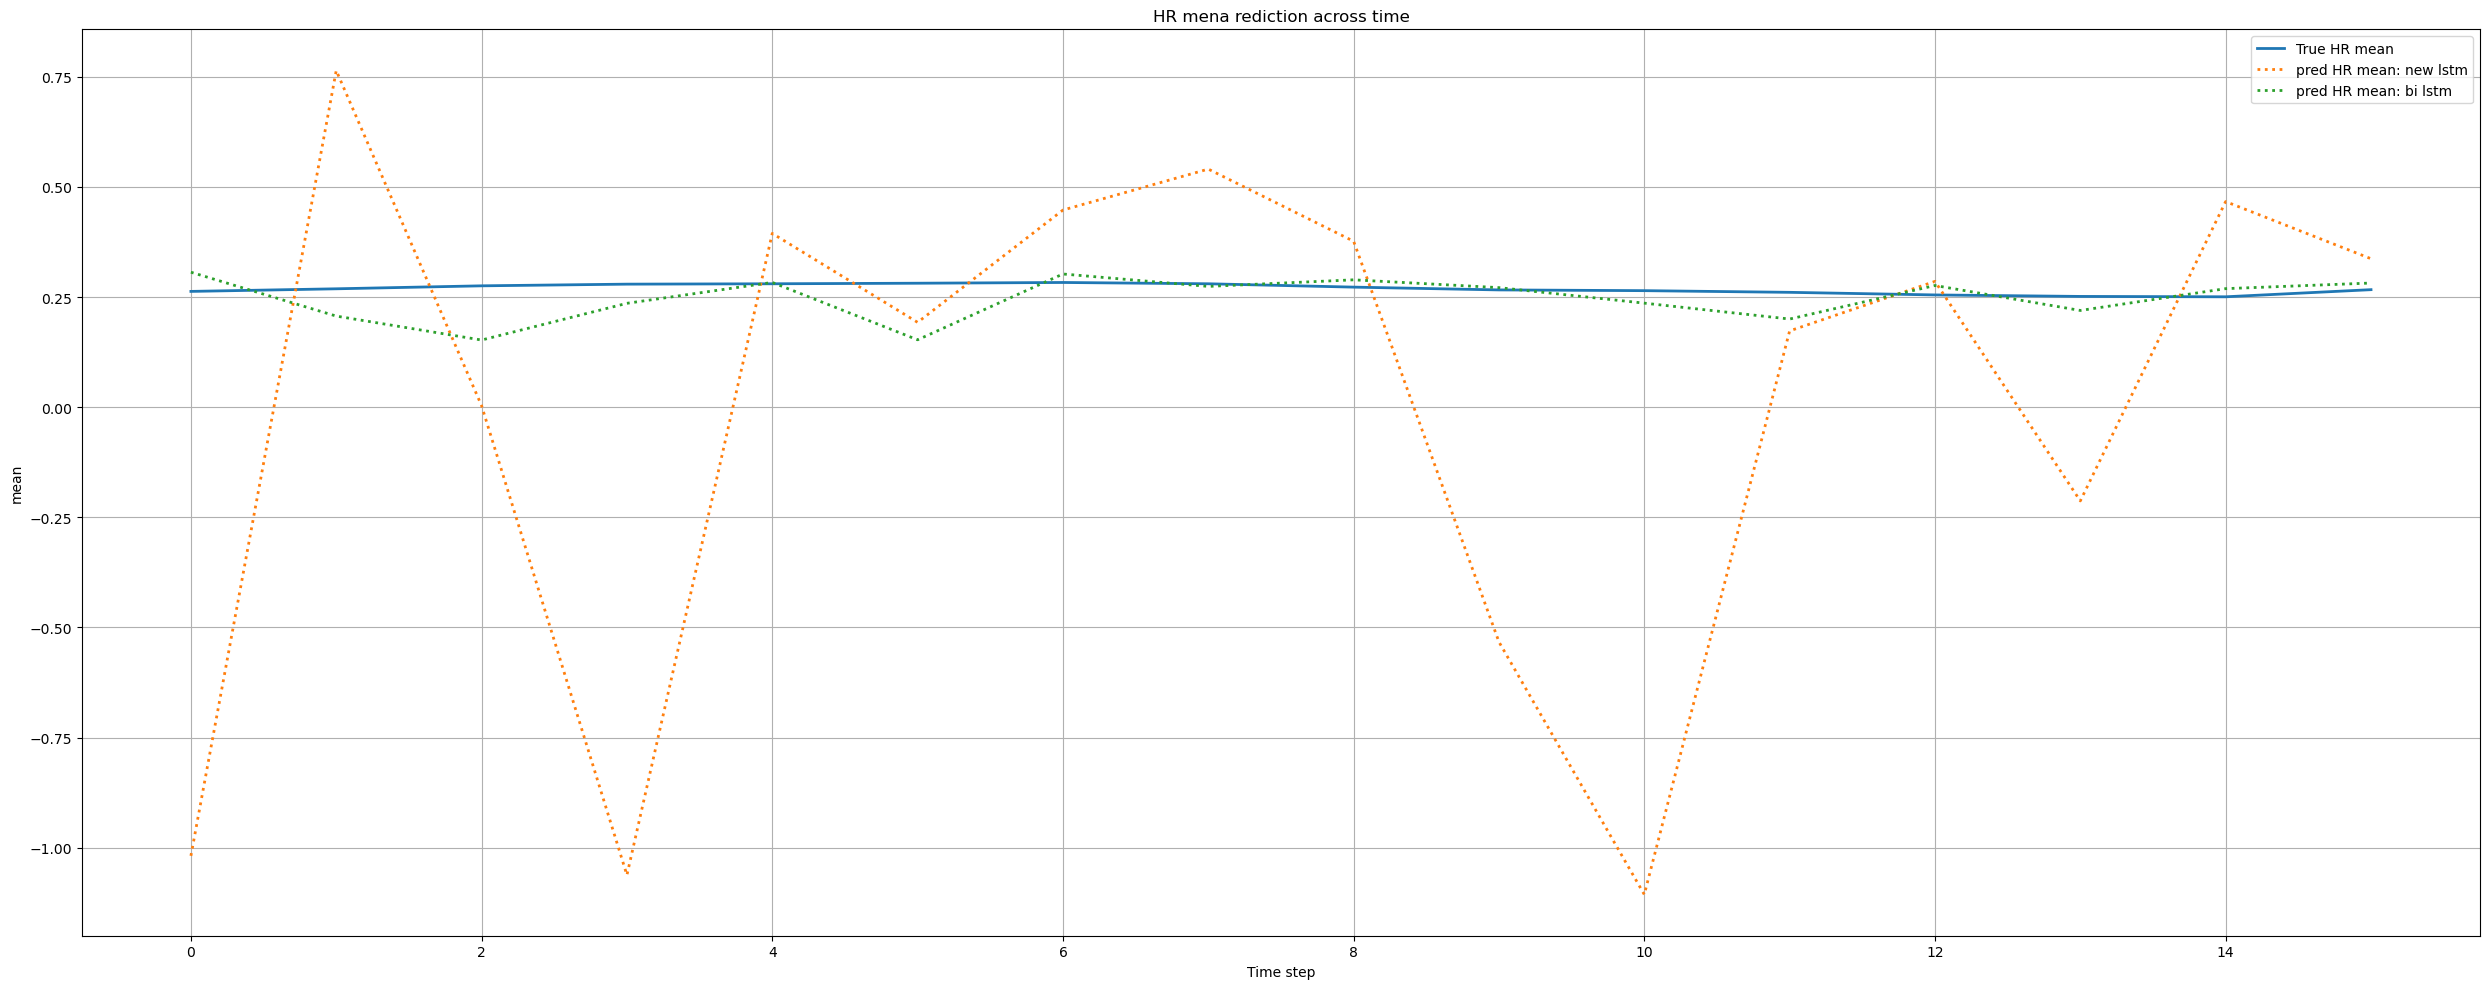

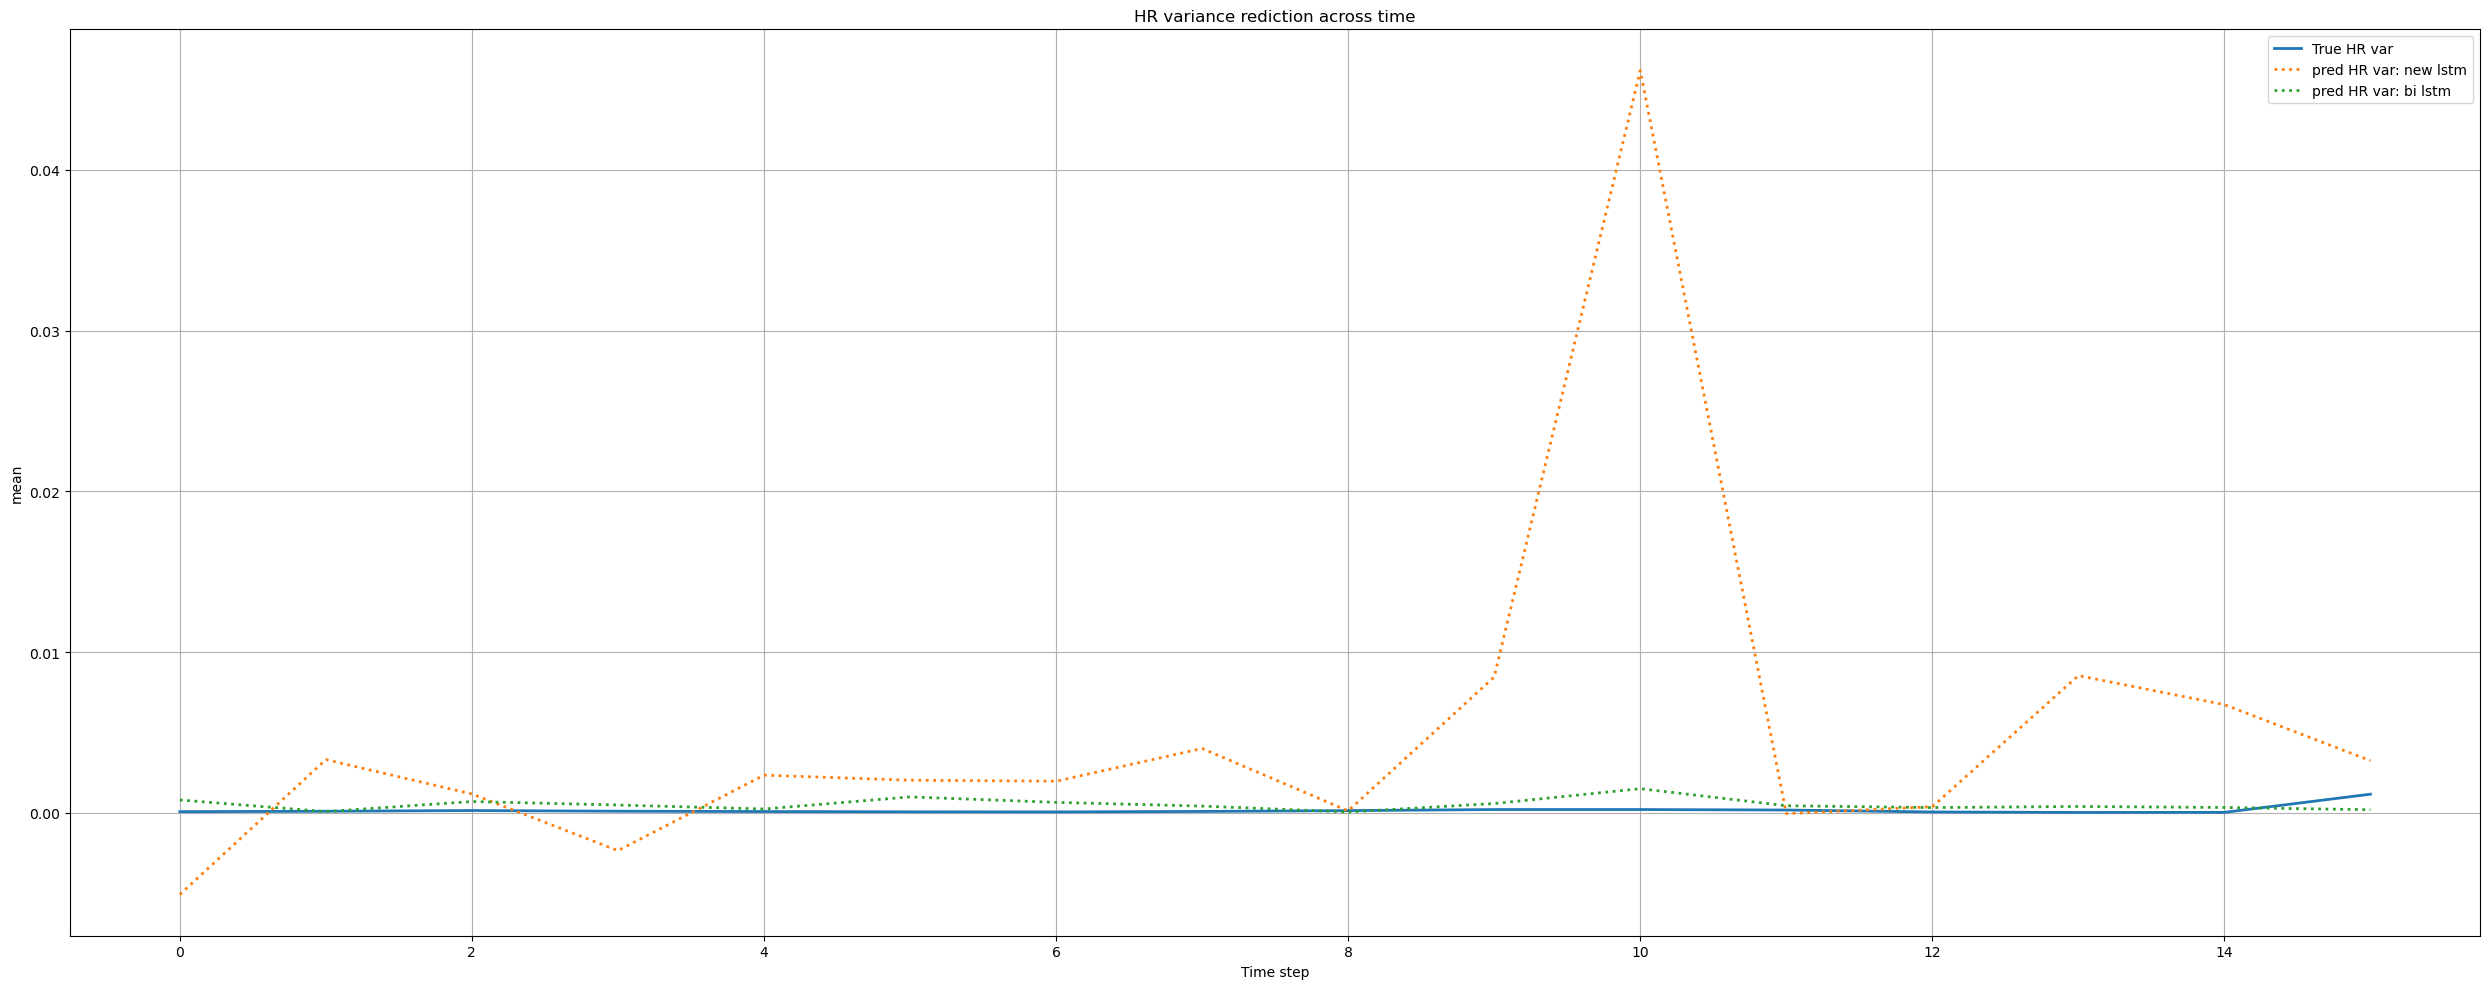

In [318]:
plt.figure(figsize=(25, 10))
# output od markovs:
plt.plot(y_true_mean_all, label="True HR mean", linewidth=2)
plt.plot(y_pred_mean_lstm_2, label="pred HR mean: new lstm", linewidth=2, linestyle=':')
plt.plot(y_pred_mean_bilstm, label="pred HR mean: bi lstm", linewidth=2, linestyle=':')

plt.title("HR mena rediction across time")
plt.xlabel("Time step")
plt.ylabel("mean")
# plt.ylim([0,1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(25, 10))
# output od markovs:
plt.plot(y_true_var_all, label="True HR var", linewidth=2)
plt.plot(y_pred_var_lstm_2, label="pred HR var: new lstm", linewidth=2, linestyle=':')
plt.plot(y_pred_var_bilstm, label="pred HR var: bi lstm", linewidth=2, linestyle=':')

plt.title("HR variance rediction across time")
plt.xlabel("Time step")
plt.ylabel("mean")
# plt.ylim([0,1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()